<a href="https://colab.research.google.com/github/ricardorobertson/Analise_de_Dados_e_Boas_Praticas/blob/main/MVP_Machine_Learning_Analytics_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Ricardo Robertson_  
**Matrícula:** _4052025002602_  
**Data:** _05/07/2026_  
**conjunto de dados:** _Dados_Estatisticos.csv e https://sistemas.anac.gov.br/dadosabertos/Voos%20e%20opera%C3%A7%C3%B5es%20a%C3%A9reas/Dados%20Estat%C3%ADsticos%20do%20Transporte%20A%C3%A9reo/_  
**Tipo de problema:** _Série temporal_  




# 1 Definição do Problema

No setor do transporte aéreo, o fator de ocupação, ou Load Factor (LF) de passageiros conforme a sua designação original, é considerado o indicador básico da eficiência de comercialização de uma companhia aérea e representa o percentual de vendas de passagens sobre a oferta de assentos em uma rota aérea. O Load Factor é determinado pela divisão entre os indicadores RPK e ASK, que são descritos abaixo:

- _RPK - Revenue Pax.km (passageiros pagantes transportados vezes quilômetros): é o resultado da multiplicação do número de passageiros pagantes transportados pela distância percorrida em cada voo._

- _ASK - Available Seat.km (assentos oferecidos vezes quilômetros): é o resultado da multiplicação do número de assentos de cada aeronave da empresa pela distância percorrida em cada voo._

_O Load Factor situa-se normalmente entre 55% e 85%, e a média mundial situa-se atualmente na casa dos 80%. Abaixo de 50% dificilmente a empresa será rentável, e acima de 85%-90%, dado que esse indicador é uma média, a empresa já estará deixando gente no chão ou perdendo passageiros para a concorrência (ponto de saturação, spill). Só empresas “charteiras” – de fretamentos turísticos – podem (e devem) operar com LF na faixa de 95%-100%._

_Fonte: Análise econômico-operacional do setor de transporte aéreo: indicadores básicos (Sérgio Bittencourt Varella Gomes e Paulus Vinicius da Rocha Fonseca)._


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de aprendizado de máquina para prever o Load Factor de passageiros de uma companhia aérea em uma rota aérea a partir de dados históricos públicos comparando uma abordagem baseline com modelos candidatos e discutindo as suas limitações.

**OBSERVAÇÃO:** Certamente, uma companhia aérea possui dados suficientes para prever o Load Factor de todas as suas rotas aéreas, mas não possui os mesmos dados para prever o indicador das companhias aéras concorrentes na mesma rota. A proposta deste trabalho é fornecer a uma companhia aéra uma forma de prever o Load Factor das companhias concorrentes em uma determinada rota e utilizar essas informaçãoes para dimensionar melhor a sua oferta de assentos e maximizar os seus ganhos.

## 1.3 Tipo de Problema

**Tipo:** Série temporal.  
**Justificativa:** O problema apresentado é de previsão de uma variável. Para atender a esse requisito, será necessário criar uma série temporal a partir de um conjunto de dados público e aplicar um método de aprendizado de máquina adequado para alcançar o objetivo.


## 1.4 Premissas, Hipóteses e Critérios de Sucesso
**Premissas:**

1. O modelo implementado no MVP será utilizado para prever o Load Factor de passageiros de uma companhia aérea na rota São Paulo - Rio de Janeiro entre os aeroportos de Congonhas em São Paulo e Santos Dumont no Rio de Janerio (Ponte aérea Rio-São Paulo). Atualmente, esta rota é operada por 3 companhias aéreas e é a rota que apresenta o maior fluxo de passageiros do Brasil movimentando cerca de 4 milhões de passageiros e 36 mil voos anuais (Fonte Internet).

2. A previsão do Load Factor só poderá ser feita para uma companhia aérea por vez. Caso haja mais de uma companhia aérea operando em uma determinada rota, o modelo do MVP permite que outra companhia seja selecionada para prever esse indicador.

**Hipóteses:**
1. Apesar do modelo do MVP prever o Load Factor somente de um aeroporto "A" para um aeroporto "B", o Load Factor da volta, aeroporto de origem "B" para o aeroporto de destino "A", pode ser considerado o mesmo, porque a maioria dos passageiros retorna para o aeroporto de origem. Caso seja necessário fazer uma previsão mais acurada, será necessário filtrar os dados da rota do aeroporto "B" para o aeroporo "A".

2. A previsão de alta/baixa do Load Factor pode indicar que a companhia aérea esteja ganhando/perdendo passageiros do/para concorrente, porque, normalmente, uma rota aérea possui um fluxo de passageiros que não varia muito para um determinado período.

**Critérios de Sucesso:**

As métricas MAE, RMSE e MAPE serão utilizadas para avaliar o resultado dos modelos. Essas métricas são baseadas no erro entre o valor predito e o valor real e são consideradas como as melhores opções para avaliar a pontuação de séries temporais.

As companhias aéreas não determinam um qual deve ser o erro para o indicador Load Factor. Elas só indicam que ele deve ficar dentro da faixa de 55% e 85% para garantir que não haja perda na rota aérea e como o Load Factor pode variar além desses limites, fica difícil definir qual o erro máximo para esse indicador.

Como o modelo de baseline é modelado considerando que o valor predito será igual ao valor atual, pode-se determinar que o erro esperado para a previsão dada por um modelo de aprendizado de máquina seja 25% menor do que o erro encontrado para a previsão do modelo de baseline. Dessa forma, o erro do modelo baseline fica definido como a referência para a avaliação dos modelos de aprendizado de máquina do MVP


# 2 Ambiente, Bibliotecas e Reprodutibilidade

Seguem as bibliotecas que serão utilizadas na implementação do MVP e a escolha da constante SEED para permitir a reprodutibilidade dos resultados.

In [53]:
import os
import sys
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)
from scipy.stats import randint, uniform
from statsmodels.tsa.seasonal import STL
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

warnings.filterwarnings("ignore")

###########
# CONTANTES
SEED = 42
SIGLA_CIAS_AEREAS = ['AZU', 'GLO', 'TAM']
COR = ['blue', 'orange', 'red']
campo = ['AZU_LF','GLO_LF','TAM_LF']

np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.2 Funções Auxiliares

Seguem as funções que foram elaboradas para dar suporte à aplicação do MVP.



In [54]:
# 2.2 Funções Auxiliares

# Função para interpolar o atributo 'LF' (Load Factor)
# Aplica interpolação linear caso existam valores NaN na coluna 'LF' ao conjunto de dados
def interpola_LF (y_dados):
  y_dados.interpolate(method='linear', inplace=True)
  return y_dados

def desfasa_LF (X_dados, y_dados):
  X_dados['LF_1'] = y_dados['LF'].shift(1)
  # Utilizado para testes
  #X_dados['LF_2'] = y_dados['LF'].shift(2)
  #X_dados['LF_3'] = y_dados['LF'].shift(3)
  #X_dados['LF_4'] = y_dados['LF'].shift(4)
  #X_dados['LF_5'] = y_dados['LF'].shift(5)

  X_dados = X_dados.dropna()
  y_dados = y_dados.loc[X_dados.index]
  return X_dados, y_dados

# Função para criar as colunas de estatísticas da feature 'LF'
# 'LF_med' (média), 'LF_min' (mínimo), 'LF_max' (máximo)
def calc_estatisticas_LF (X_dados, y_dados):

  # Tamanho da janela móvel utilizada nos cálculos das estatíscas da série temporal
  # O valor da janela já está otimizado
  janela = 5

  colunas = ['LF_1']
  X_dados['LF_med'] = X_dados[colunas].rolling(window=janela, min_periods=1, closed='left').mean().mean(axis=1)
  X_dados['LF_min'] = X_dados[colunas].rolling(window=janela, min_periods=1, closed='left').min().mean(axis=1)
  X_dados['LF_max'] = X_dados[colunas].rolling(window=janela, min_periods=1, closed='left').max().mean(axis=1)
  X_dados['LF_std'] = X_dados[colunas].rolling(window=janela, min_periods=1, closed='left').std().mean(axis=1)
  X_dados.dropna(inplace=True)
  y_dados = y_dados.loc[X_dados.index]

  # Utilizado para testes
  #colunas = ['LF_1','LF_2','LF_3']
  #colunas = ['LF_1','LF_2','LF_3', 'LF_4', 'LF_5']

  return X_dados, y_dados

# Previsão dos componente de tendência e sazonalidade da série temporal
# Esta função extrapola a tendência usando regressão polinomial
# e a sazonalidade repetindo o último ciclo.
def predicoes_tendencia_sazonalidade (y_tendencia_treino, y_sazonalidade_treino, horizonte_previsao):
  h = horizonte_previsao
  n = 2 # Grau do polinômio utilizado para a extrapolação da tendência. Já está otimizado.

  # Extrapolação da tendência
  # Usa o índice da série de treino da tendência como a variável de tempo
  x_treino_tend = np.arange(len(y_tendencia_treino))
  y_treino_tend = y_tendencia_treino.values

  # Ajusta o polinômio à componente da tendência
  coeficientes = np.polyfit(x_treino_tend, y_treino_tend, deg=n)
  funcao_polinomio = np.poly1d(coeficientes)

  # Gera pontos futuros para o horizonte de previsão assumindo um índice
  # inteiro contínuo a partir do último ponto de treino
  x_future_trend = np.arange(len(y_tendencia_treino), len(y_tendencia_treino) + h)

  # Extrapola a tendência para datas futuras
  tendencia_futura = funcao_polinomio(x_future_trend)

  # Extrapolação da sazonalidade
  period = 12 # Dados mensais
  sazonalidade_futura = np.zeros(h)

  if len(y_sazonalidade_treino) >= period:
      # Pega o último ciclo sazonal completo da sazonalidade de treino
      seasonal_cycle = y_sazonalidade_treino.iloc[-period:].values
      # Repete este ciclo para corresponder ao comprimento do horizonte de previsão
      sazonalidade_futura = np.tile(seasonal_cycle, (h // period) + 1)[:h]
  elif len(y_sazonalidade_treino) > 0:
      # Se não houver dados suficientes para um ciclo completo, repete o que estiver disponível
      seasonal_cycle = y_sazonalidade_treino.values
      sazonalidade_futura = np.tile(seasonal_cycle, (h // len(seasonal_cycle)) + 1)[:h]
  # Se y_sazonalidade_treino estiver vazio, sazonalidade_futura permanece zeros, o que é apropriado.

  return tendencia_futura, sazonalidade_futura

# Decomponhe a série temporal em sasonalidade, tendência e resíduos
def decomposicao_STL(X_serie):
    stl = STL(X_serie, period=12)
    X_decomposto = stl.fit()
    X_tendencia = X_decomposto.trend
    X_sazonal = X_decomposto.seasonal

    return X_tendencia, X_sazonal

# Exibe resultados como DataFrame ordenável
def exibe_tabela_resultados(results_dict):
    return pd.DataFrame(results_dict).T

# Calcula métricas básicas MAE e RMSE para séries temporais
def avalia_serie_temporal (y_real, y_predito):
    return {
        "MAE": mean_absolute_error(y_real, y_predito),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_predito)),
        "MAPE %": mean_absolute_percentage_error(y_real, y_predito)*100
    }

# Baseline para séries temporais
# Considera o valor a ser previsto como o valor anterior
def BaselineTemporal (X_, y_):
  X_deslocado = X_.copy()
  X_deslocado ['LF_1'] = y_.shift(1)
  return (X_deslocado)


# 3 Conjunto de Dados

## 3.1 Fonte dos dados

O conjunto de dados "Dados_Estatisticos.csv" foi utilizado para o desenvolvimento do MVP e pode ser encontrado no site da ANAC (Angência Nacional de Aviação Civil) "https://sistemas.anac.gov.br/dadosabertos/Voos%20e%20opera%C3%A7%C3%B5es%20a%C3%A9reas/Dados%20Estat%C3%ADsticos%20do%20Transporte%20A%C3%A9reo/"

Ele possui os dados estatísticos mensais de todas as rotas aéreas com origem e destino no Brasil de janerio/2000 a abril/2026 e possibilita que o indicador Load Factor de passageiros mensal de uma rota seja calculado utilizando os indicadores RPK e ASK presentes no conjunto de dados.


##3.2 Carga dos Dados

**Comentário:**
Como o arquivo original ('Dados_Estatisticos.csv') possui 339,2MB, o tempo de leitura estava variando de 25 a 30 minutos e, em alguns casos, a conexão era terminada sem que todo o arquivo fosse lido. Para evitar esses incômodos, o arquivo original foi filtrado separadamente para conter somente os registros de interesse do MVP. Após essa operação, o arquivo ficou com o tamanho de 570kB e o tempo de leitura ficou em 0,466 segundos. Para o MVP, o arquivo csv utilizado será o arquivo filtrado 'Estatisticas_Ponte_Aerea.csv', que será lido do repositório do usuário no Github.

In [55]:
# 3.2 Carga dos Dados

# Carrega o arquivo 'Estatisticas_Ponte_Aerea.csv' do GitHub
url = 'https://github.com/ricardorobertson/Machine_Learning_Analytics/raw/main/Estatisticas_Ponte_Aerea.csv'
df = pd.read_csv(url, encoding='utf-8-sig', sep=';', header = 0)



##3.3 Ajustes Preliminares

Antes de iniciar a análise exploratória de dados, será necessário complementar o conjunto de dados com os atributos que serão essencias para criar a série temporal que será utilizada para prever a variável target.


###3.3.1 Alteração do Tipo de Dados das Colunas 'ANO' e 'MES'

Será necessário alterar o tipo de dados das colunas 'ANO' e 'MES' de int64 para Int64 para evitar que ocorra alguma alteração no tipo de dados desses atributos durante a execução do notebook.

In [56]:
# 3.3.1 Alteração do Tipo de Dados das Colunas 'ANO' e 'MES'

# Altera o tipo de dados das colunas 'ANO' e 'MES' de int64 para Int64
df['ANO'] = df['ANO'].astype('Int64')
df['MES'] = df['MES'].astype('Int64')

# Preserva o dataframe original
df_1 = df.copy()

###3.3.2 Inclusão da Variável Target 'LF' - Load Factor

A variável target Load Factor é determinada pelo quociente entre os atributos 'RPK' (assentos vendidos) e 'ASK' (assentos disponíveis). Como o conjunto de dados ainda não possui esse atributo, será necessário incluir a coluna 'LF' para possibilitar crição de novos atributos, que serão utilizados para a criação da série temporal.


In [57]:
# 3.3.2 Inclusão da Coluna 'LF', Load Factor

# Adiciona a coluna da variável target, 'LF' (Load Factor), ao dataframe
# O Load Factor é o quociente entre os atributos RPK e ASK

df_1['LF'] = df_1['RPK'] / df_1['ASK']

###3.3.3 Verificação de Anos e Meses Faltantes

Antes da separação dos dados entre treino e teste, será necessário garantir que a série temporal esteja completa com todos os anos e todos os meses para evitar uma quebra na sequência temporal.

Caso uma nova instância seja incluída no conjunto de dados devido a falta do ano ou do mês, o atributo Load Factor será criado com o valor NaN. Durante o tratamento dos dados, os valores NaN serão substituídos por valores interpolados linearmente.

In [58]:
# 3.3.3 Verificação de Datas Faltantes

# A sequência de ano+mês deve ser verificada para identificar anos e/ou meses faltantes

# Verifica se ano e mês são numéricos
df_1['ANO'] = pd.to_numeric(df_1['ANO'], errors='coerce')
df_1['MES'] = pd.to_numeric(df_1['MES'], errors='coerce')

for cia_aerea in SIGLA_CIAS_AEREAS:
  print(cia_aerea)

  # Filtra as linhas por companhia aérea
  df_cia_aerea = df[df['EMPRESA_SIGLA'] == cia_aerea]

  # Encontra o menor e o maior mês
  mes_ini = df_cia_aerea['MES'].min()
  mes_fim = df_cia_aerea['MES'].max()
  ano_ini = df_cia_aerea['ANO'].min()
  ano_fim = df_cia_aerea['ANO'].max()
  mes_fim_2026 = df_cia_aerea[df_cia_aerea['ANO'] == 2026]['MES'].max()

  # Percorre os anos sequencialmente para verificar se há algum ano/mês faltante
  for ano in range(ano_ini, ano_fim + 1):
    # Se o ano é '2026', verifica meses faltantes até o último mês de 2026
    if ano == ano_fim:
      # Percorre os meses do ano de 2026
      for mes in range(1, mes_fim_2026 + 1):
        # Se o mês foi encontado no conjunto de dados, pula para o próximo
        if ((df_1['ANO'] == ano) & (df_1['MES'] == mes) & (df_1['EMPRESA_SIGLA'] == cia_aerea)).any():
          continue
        else:
          # Se o mês está faltando no ano, inclui uma nova linha no conjunto de dados
          indice_nova_df_1 = len(df_1)
          df_1.loc[indice_nova_df_1, ['ANO', 'MES', 'EMPRESA_SIGLA']] = [ano, mes, cia_aerea]
          print("Incluiu nova linha no ano, mês: 2026 ", mes)
    else:
      # Percorre os meses do ano em verificação
      for mes in range(1, mes_fim + 1):
        # Se o mês foi encontado no conjunto de dados, pula para o próximo
        if ((df_1['ANO'] == ano) & (df_1['MES'] == mes) & (df_1['EMPRESA_SIGLA'] == cia_aerea)).any():
          continue
        else:
          # Se o mês está faltando no ano, inclui uma nova linha no conjunto de dados
          if (cia_aerea == 'AZU'):
            if ((df_1['ANO'] <= 2019) & (df_1['MES'] < 9)).any():
              continue
            else:
              indice_nova_df_1 = len(df_1)
              df_1.loc[indice_nova_df_1, ['ANO', 'MES', 'EMPRESA_SIGLA']] = [ano, mes, cia_aerea]
              print("Incluiu nova linha no ano, mês:", ano, mes)
          else:
            indice_nova_df_1 = len(df_1)
            df_1.loc[indice_nova_df_1, ['ANO', 'MES', 'EMPRESA_SIGLA']] = [ano, mes, cia_aerea]
            print("Incluiu nova linha no ano, mês:", ano, mes)


AZU
GLO
Incluiu nova linha no ano, mês: 2008 1
Incluiu nova linha no ano, mês: 2020 4
TAM


###3.3.4 Inclusão da Coluna 'DATA'

Como o objetivo do MVP é a previsão do Load Factor de uma companhia aérea, será necessário criar a coluna 'DATA' com o tipo datetime64[ns] para ser utilizado como índice da série temporal que será criada a partir do conjunto de dados original. Esta coluna será obtida pela concatenação dos valores das colunas 'ANO', 'MES' e o primeiro dia do mês.

In [59]:
# 3.3.4 Inclusão da Coluna 'DATA'

# Cria a coluna 'DATA' com o tipo Datetime utilizando as colunas 'ANO' e 'MES'
df_1['DATA'] = pd.to_datetime(df_1['ANO'].astype(str) + '-' + df_1['MES'].astype(str) + '-01')

# Ordena a coluna 'DATA'
df_1.sort_values(by='DATA', inplace=True)


##3.4 Visão Geral do Conjunto de Dados

O conjunto de dados 'Estatisticas_Ponte_Aerea.csv' apresenta 725 instâncias com 40 atributos sendo 18 categóricos, 21 numéricos e 1 data. Entretanto, somente os atributos 'LF' (variável target) e 'DATA' serão utilizados para criar os novos atributos da série temporal. Os demais serão descartados, porque não serão utilizados na etapa de aprendizado de máquina.

Apesar do conjunto de dados possuir 725 instâncias, aproximadamente 1/3 será utilizado para treinar os modelos de aprendizado de máquina. Esse número conrresponde ao total de dados de uma companhia aérea que opera na Ponte Aérea. Será necessário expandir os dados para aumentar o número de instâncias que treinarão os modelos de aprendizado de máquina.

Verificando os atributos 'DATA' e 'LF' identifica-se que o atributo 'DATA' não possui valores nulos. Por outro lado , o atributo 'LF' possui 4 nulos que serão interpolados linearmente após a separação dos dados entre treino e teste para evitar o vazamento de dados.

Outro ponto importante para manter os dados íntegros é a verificação de instâncias duplicadas. Não foram encontradas instâncias duplicadas no conjunto de dados.

As impressões abaixo exibem a listegem dos tipos de dados, a quantidade de valores faltantes em cada atributo e a existência de instâncias duplicatas. Ao final, são impressas algumas instâncias aleatoriamente do conjunto de dados.


In [60]:
# 3.4 Visão Geral do conjunto de dados
# Impressão do tipo de cada campo do conjunto de dados.

print("Formato do conjunto de dados:", df_1.shape)
print("\nTipos de dados:")
display(df_1.dtypes.to_frame("tipo"))

Formato do conjunto de dados: (725, 40)

Tipos de dados:


,tipo
EMPRESA_SIGLA,object
EMPRESA_NOME,object
EMPRESA_NACIONALIDADE,object
ANO,Int64
MES,Int64
AEROPORTO_DE_ORIGEM_SIGLA,object
AEROPORTO_DE_ORIGEM_NOME,object
AEROPORTO_DE_ORIGEM_UF,object
AEROPORTO_DE_ORIGEM_REGIAO,object
AEROPORTO_DE_ORIGEM_PAIS,object


In [61]:
# 3.4 Visão Geral do Conjunto de Dados
# Verificação de valores ausentes

print("\nValores ausentes por coluna:")
display(df_1.isna().sum().to_frame("ausentes"))



Valores ausentes por coluna:


,ausentes
EMPRESA_SIGLA,0
EMPRESA_NOME,2
EMPRESA_NACIONALIDADE,2
ANO,0
MES,0
AEROPORTO_DE_ORIGEM_SIGLA,2
AEROPORTO_DE_ORIGEM_NOME,2
AEROPORTO_DE_ORIGEM_UF,2
AEROPORTO_DE_ORIGEM_REGIAO,2
AEROPORTO_DE_ORIGEM_PAIS,2


In [62]:
# 3.4 Visão Geral do Conjunto de Dados
# Verificação da existência de instâncias duplicadas

print("\nDuplicatas:", df_1.duplicated().sum())



Duplicatas: 0


In [63]:
# 3.4 Visão Geral do Conjunto de Dados
# Impressãso de linhas aleatórias do conjunto de dados.

display(df_1.sample(5, random_state=SEED))

,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_UF,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,...,DECOLAGENS,CARGA_PAGA_KM,CARGA_GRATIS_KM,CORREIO_KM,ASSENTOS,PAYLOAD,HORAS_VOADAS,BAGAGEM_KG,LF,DATA
323,AZU,AZUL LINHAS AÉREAS BRASILEIRAS S/A,BRASILEIRA,2014,2,SBSP,SÃO PAULO,SP,SUDESTE,BRASIL,...,4.0,106872.0,0.0,0.0,436.0,47028.0,"3,94",3547.0,0.855505,2014-02-01
503,AZU,AZUL LINHAS AÉREAS BRASILEIRAS S/A,BRASILEIRA,2020,8,SBSP,SÃO PAULO,SP,SUDESTE,BRASIL,...,148.0,1931748.0,21594.0,0.0,10696.0,828355.0,"176,217",25543.0,0.594708,2020-08-01
550,GLO,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,BRASILEIRA,2021,8,SBSP,SÃO PAULO,SP,SUDESTE,BRASIL,...,235.0,4042836.0,920856.0,0.0,39766.0,4602911.0,"217,917",68700.0,0.703692,2021-08-01
40,TAM,TAM LINHAS AÉREAS S.A.,BRASILEIRA,2002,5,SBSP,SÃO PAULO,SP,SUDESTE,BRASIL,...,763.0,36737250.0,3537390.0,0.0,93086.0,12513200.0,"647,72",287122.0,0.502793,2002-05-01
363,AZU,AZUL LINHAS AÉREAS BRASILEIRAS S/A,BRASILEIRA,2015,6,SBSP,SÃO PAULO,SP,SUDESTE,BRASIL,...,4.0,0.0,0.0,0.0,436.0,56178.0,"3,84",3550.0,0.779817,2015-06-01


## 3.5 Dicionário de Dados

Segue a descrição de cada atributo do conjunto de dados.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| EMPRESA_SIGLA | categórica | _Sigla da companhia aérea._ | não | _Será utilizada para a filtragem dos dados de interesse. Entretanto, ele não será necessário para a previsão da variável target._ |
| EMPRESA_NOME | categórica | _Empresa Aérea responsável por operar as etapas._ | não | _O atributo não será necessário para a previsão da variável target._ |
| EMPRESA_NACIONALIDADE | categórica | _Nacionalidade da companhia aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| ANO | categórica | _Refere-se à data prevista para início da primeira etapa de cada voo._ | não | _O atributo será necessário para gerar o atributo 'DATA'. Entretanto, ele não será necessário para a previsão da variável target._ |
| MES | categórica | _Refere-se à data prevista para início da primeira etapa de cada voo._ | não | _O atributo será necessário para gerar o atributo 'DATA'. Entretanto, ele não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_ORIGEM_SIGLA | categórica | _Sigla do aeroporto de origem do voo conforme codificação ICAO._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_ORIGEM_NOME | categórica | _Nome do aeroporto de ogirem do voo._ | não | _O atributo não será necessário para a previsão da variável target_ |
| AEROPORTO_DE_ORIGEM_UF | categórica | _Unidade da federação onde se localiza o aeroporto de origem._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_ORIGEM_REGIAO | categórica | _Região do país onde se localiza o aeroporto de origem._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_ORIGEM_PAIS | categórica | _País onde se localiza o aeroporto de origem._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_ORIGEM_CONTINENTE | categórica | _Continente onde se localiza o aeroporto de origem._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_DESTINO_SIGLA | categórica | _Sigla do aeroporto de origem do voo conforme codificação ICAO._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_DESTINO_NOME | categórica | _Nome do aeroporto de destino do voo._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_DESTINO_UF | categórica | _Unidade da federação onde se localiza o aeroporto de destino._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_DESTINO_REGIAO | categórica | _Região do país onde se localiza o aeroporto de destino._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_DESTINO_PAIS | categórica | _País onde se localiza o aeroporto de destino._ | não | _O atributo não será necessário para a previsão da variável target._ |
| AEROPORTO_DE_DESTINO_CONTINENTE | categórica | _Continente onde se localiza o aeroporto de destino._ | não | _O atributo não será necessário para a previsão da variável target._ |
| NATUREZA | categórica | _Refere-se à natureza das etapas, e possui o valor “Doméstico" caso as etapas tenham o pouso e a decolagem realizadas no Brasil e sejam operadas por Empresas brasileiras ou possuem o valor “Internacional" caso contrário._ | não | _O atributo não será necessário para a previsão da variável target._ |
| GRUPO_DE_VOO | categórica | _Refere-se ao tipo de operação das etapas. Para o MVP GRUPO_DE_VOO = 'REGULAR' (Voos regulares das companhias aéreas)._ | não | _Será utilizada para a filtragem dos dados de interesse. Entretanto, ele não será necessário para a previsão da variável target._ |
| PASSAGEIROS_PAGOS | numérica | _Número de passageiros que pagaram a passagem. Número por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| PASSAGEIROS_GRATIS | numérica | _Número de passageiros que não pagaram a passagem. Número por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| CARGA_PAGA_KG | numérica | _Refere-se ao volume de Carga Paga (kg) em cada quilômetro, ou seja, a soma do produto entre a quantia (kg) de carga paga e a distâncias das etapas. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| CARGA_GRATIS_KG | numérica | _Refere-se ao volume de Carga Grátis (kg) em cada quilômetro, ou seja, a soma do produto entre a quantia (kg) de carga grátis e a distâncias das etapas. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| CORREIO_KG | numérica | _Refere-se ao volume de Correio (kg) em cada quilômetro, ou seja, a soma do produto entre a quantia (kg) de correio e a distâncias das etapas. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| ASK | numérica | _Available Seat.km (assentos oferecidos vezes quilômetros): é o resultado da multiplicação do número de assentos de cada aeronave da empresa pela distância percorrida em cada voo. Número por mês na rota aérea._ | não | _O atributo será necessário para determinar o valor da variável target Load Factor, mas não será utilizado pelas metodologias de aprendizado de máquina._ |
| RPK | numérica | _Revenue Pax.km (passageiros pagantes transportados vezes quilômetros). Número por mês na rota aérea._ | não | _O atributo será necessário para determinar o valor da variável target Load Factor, mas não será utilizado pelas metodologias de aprendizado de máquina._ |
| ATK | numérica | _(Available tonne kilometer) Refere-se ao volume de Tonelada Quilômetro Oferecida. Número por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| RTK | numérica | _(Revenue tonne kilometer) Refere-se ao volume de Toneladas Quilômetros Transportadas. Número por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| COMBUSTIVEL_LITROS | numérica | _Refere-se à quantidade, em litros, de combustível consumida pela aeronave na execução da referida etapa. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| DISTANCIA_VOADA_KM | numérica | _Distância voada por mês na rota aérea. Número por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| DECOLAGENS | numérica | _Refere-se ao número de decolagens que ocorreram entre os aeródromos de origem e destino da etapa. Número por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| CARGA_PAGA_KM | numérica | _Refere-se ao volume de Carga Paga (kg) em cada quilômetro, ou seja, a soma do produto entre a quantia (kg) de carga paga e a distâncias das etapas. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| CARGA_GRATIS_KM | numérica | _Refere-se ao volume de Carga Grátis (kg) em cada quilômetro, ou seja, a soma do produto entre a quantia (kg) de carga grátis e a distâncias das etapas. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| CORREIO_KM | numérica | _Refere-se ao volume de Correio (kg) em cada quilômetro, ou seja, a soma do produto entre a quantia (kg) de correio e a distâncias das etapas. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| ASSENTOS | numérica | _É o número de assentos disponíveis em cada etapa de voo de acordo com a configuração da aeronave na execução da etapa. Número por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| PAYLOAD | numérica | _É a capacidade total de peso na aeronave, expressa em quilogramas, disponível para efetuar o transporte de passageiros, carga e correio. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| HORAS_VOADAS | numérica | _Número de horas voadas. Número por mês na rota aérea_ | não |_O atributo não será necessário para a previsão da variável target._ |
| BAGAGEM_KG | numérica | _Peso das bagagens transportadas. Quantidade por mês na rota aérea._ | não | _O atributo não será necessário para a previsão da variável target._ |
| LF | numérica | _Fator de aproveitamento. Valor obtido pelo quociente de RPK e ASK (Load Factor). Número por mês na rota aérea._ | sim | _Variáve target_ |
| DATA | data | _Data em que foi gerada a estatística mensal._ | sim | _Obtida pela concatenação dos atributos 'ANO' e 'MES'._ |


# 4 Análise Exploratória dos Dados

Conforme descrito anteriormente, o arquivo CSV utilizado no MVP foi filtrado do arquivo original "Dados_Estatisticos.csv" para conter somente os voos das companhias aéreas AZUL, GOL e TAM na rota São Paulo-Rio de Janeiro entre os aeroportos de Congonhas e Santos Dumont (Ponte Aérea Rio-São Paulo).

Como o conjunto de dados será utilizado para implementar uma série temporal para prever o Load Factor ('LF') somente esse atributo e o atributo 'DATA' são de relevância para o MVP. Por isso, somente o atributo 'LF' foi analisado. Os demais atributos não serão utilizados na etapa de apredizado de máquina.


##4.1 Análise do Load Factor

Como a 'LF' é o quociente entre os atributos 'RPK' e 'ASK', o resultado desse cálculo será sempre um número entre 0 e 1 e como todos os atributos serão criados a partir do 'LF', eles também estarão contidos entre 0 e 1. Portanto, não será necessário normalizar esse atributo.  

Para analisar o Load Factor das companhias aéreas que operam na Ponte Aérea Rio-São Paulo, foram plotados os gráficos:

- Série temporal: para visualizar a evolução do Load Factor ao longo do tempo;
- Boxplot: para comparar os dados estatísticos do Load Factor;
- Histograma de diferenças: para visualizar o estado do Load Factor (alta, baixa, estacionário); e
- Matriz de correlação: para identificar a interação entre as companhias aéreas.



###4.1.1 Gráficos Temporais


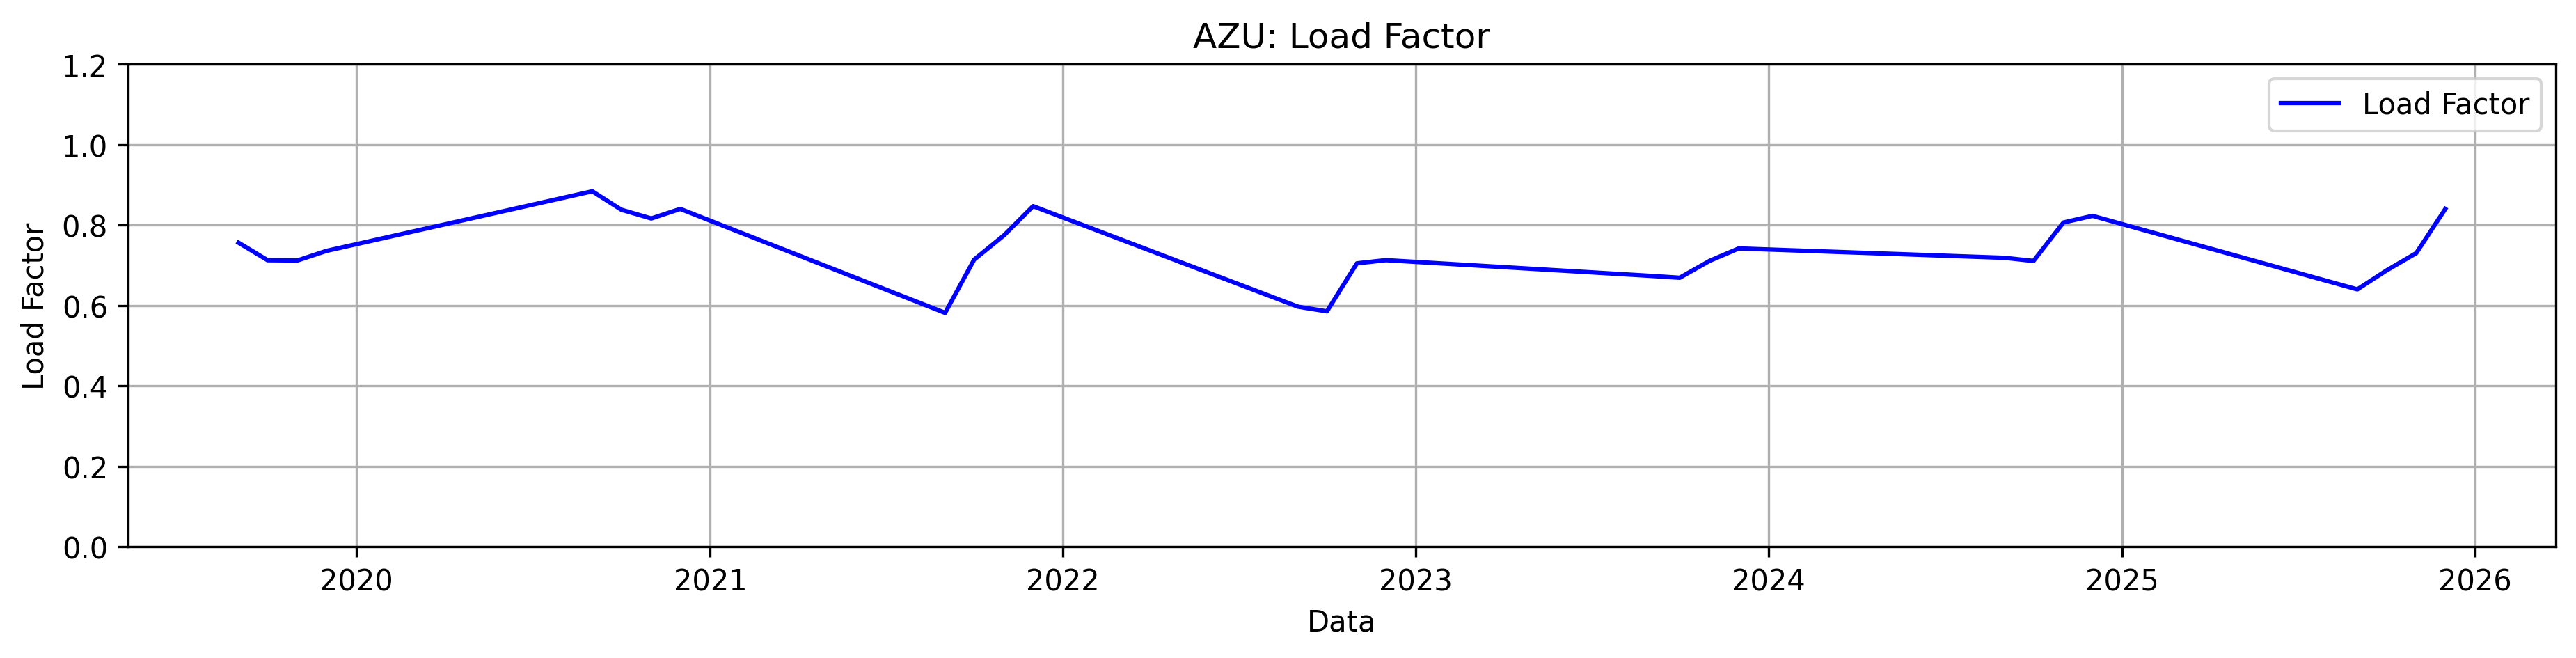

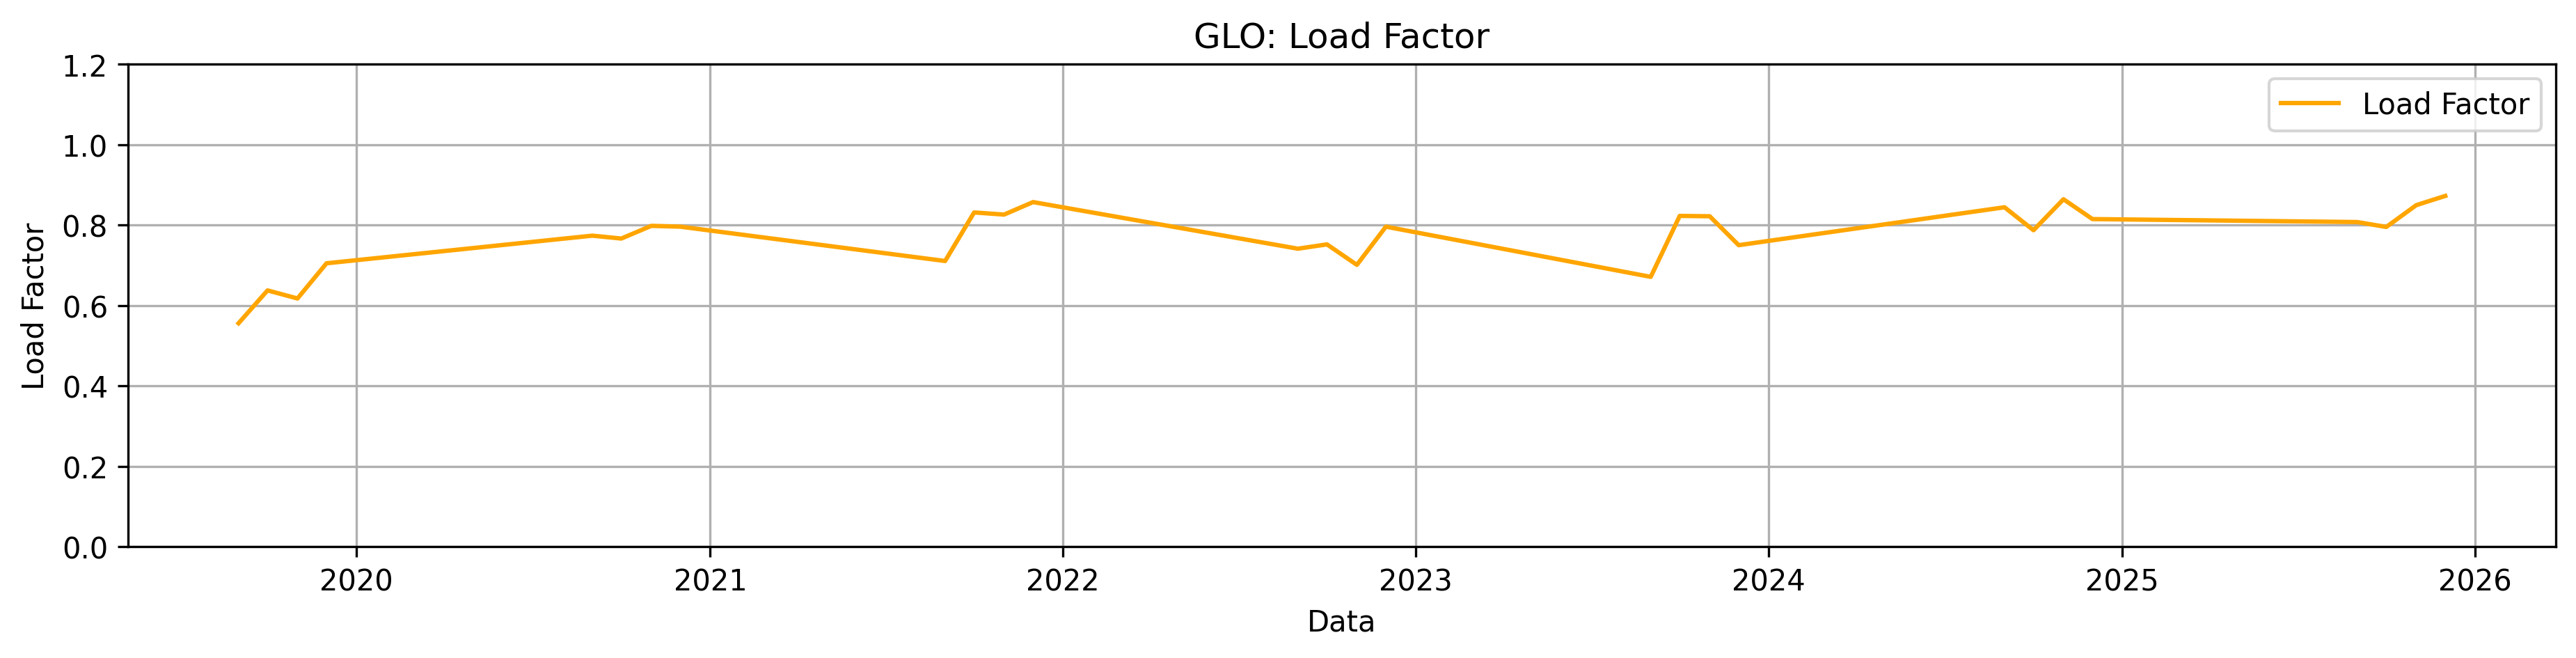

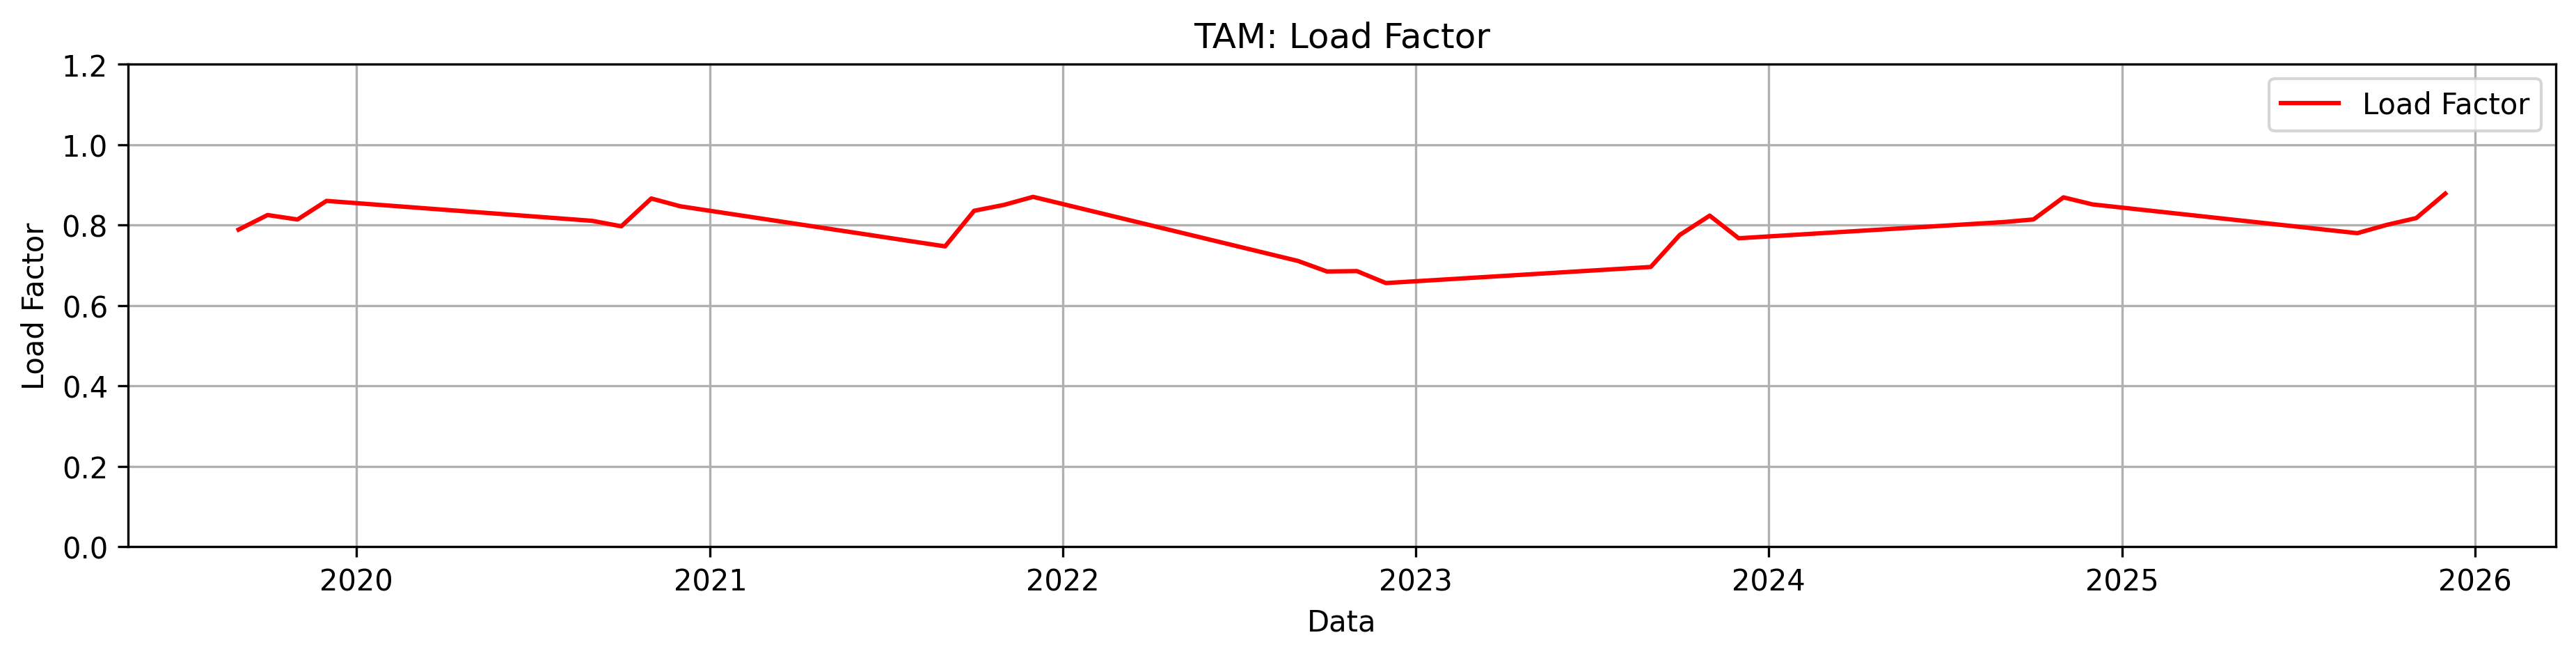

In [64]:
# 4.1.1 Gráficos Temporais

# Plota o gráfico de variação temporal do Load Factor das companhias aéreas

df_corr = pd.DataFrame()

# Filtra o LF das cias aéreas de set/2019 a abr/2026, que é o período em que as 3 empresas
# da ponte aérea operaram juntas
df_filtrado = df_1[
    (df_1['EMPRESA_SIGLA'].isin(['AZU', 'GLO', 'TAM'])) &
    (df_1['ANO'] >= 2019) &
    (df_1['MES'] >= 9)
][['ANO', 'MES', 'EMPRESA_SIGLA', 'LF']]

# Plota o 'LF' das cias aéreas no período em que que todas as 3 operaram
for idx, sigla in enumerate(SIGLA_CIAS_AEREAS):
  #print(sigla)
  # Filtra a cia aérea atual
  df_empresa = df_filtrado[df_filtrado['EMPRESA_SIGLA'] == sigla].copy()

  # Prepara um dataframe com os LFs de cada cia aérea para gerar a matriz de correlação
  coluna = sigla+'_LF'
  valores = df_empresa.loc[df_empresa['EMPRESA_SIGLA'] == sigla, 'LF'].to_numpy()
  df_corr.insert(loc=0, column=coluna , value=valores)

  # Cria a coluna 'DATA' para ser utilizada como referência no eixo x do gráfico
  df_empresa['DATA'] = pd.to_datetime(df_empresa['ANO'].astype(str) + '-' + df_empresa['MES'].astype(str) + '-01')
  df_empresa.set_index('DATA', inplace=True)
  df_empresa.sort_index(inplace=True)

  plt.figure(figsize=(15, 3), dpi=300)
  plt.plot(df_empresa.index, df_empresa['LF'], color=COR[idx % len(COR)], label='Load Factor')
  plt.title(f'{sigla}: Load Factor')
  plt.xlabel('Data')
  plt.ylabel('Load Factor')
  plt.legend()
  plt.grid(True)
  plt.ylim(0, 1.2)
  plt.show()


**Análise dos Gráficos Temporais**

Analisando os gráficos, verifica-se que a variação do Load Factor das companhias aéreas é bem semelhante possuindo pequenas variações. Pode-se inferir que a margem de ganho de uma companhia sobre as outras é pequena.


###4.1.2 Boxplot

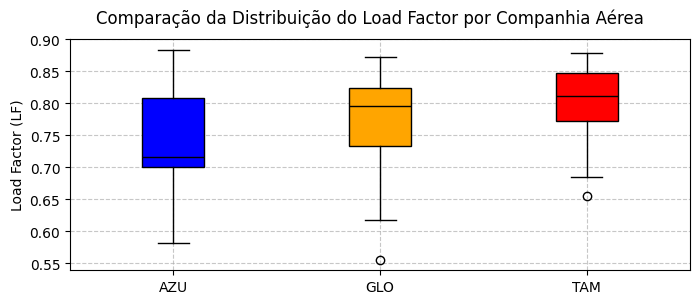

In [65]:
# 4.1.2 Boxplot

# Plota o gráfico do 'LF' das cias aéreas

# Boxplot de comparação dos Load Factors por companhia aérea
all_lf_data = []
for cia in SIGLA_CIAS_AEREAS:
  # Filtra a companhia aérea e seleciona a coluna 'LF'
  lf_series = df_filtrado[df_filtrado['EMPRESA_SIGLA'] == cia]['LF'].dropna()
  all_lf_data.append(lf_series)

fig = plt.figure(figsize=(8, 3))
fig.suptitle('Comparação da Distribuição do Load Factor por Companhia Aérea')
ax = fig.add_subplot(111)

bp = ax.boxplot(all_lf_data, patch_artist=True, medianprops={'color': 'black'}) # Use ax.boxplot and set medianprops here
for box, color in zip(bp['boxes'], COR):
    box.set_facecolor(color)
    box.set_edgecolor('black')
    box.set_linewidth(1)

ax.set_xticklabels(SIGLA_CIAS_AEREAS)
plt.ylabel('Load Factor (LF)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Análise dos Boxplots**

Nos gráficos de boxplot, verifica-se que a TAM apresenta os maiores valores de Load Factor e é seguida pela GOL e AZUL. Além disso, o intervalo interquartil é simétrico e se mantém em valores altos indicando que a TAM apresenta um bom fator de ocupação em suas aeronaves da Ponte Aérea.

A GOL apresenta um intervalo interquartil dentro dos limites esperados para o Load Factor (55% e 85%) com uma maior concentração no 3º quartil, mas apresenta dispersão no 1º quartil e um limite inferior baixo indicando que o fator de ocupação de suas aeronaves pode chegar a valores próximos do limite de 55%.

Na AZUL, o intervalo interquartil se situa dentro dos limites esperados para o Load Factor, mas os dados estão concentrados em uma pequena faixa do 1º quartil. Além disso, o limite inferior se situa muito próximo de 55% indicando que a AZUL necessita aumentar a faixa do 3º quartil para diminuir os assentos não ocupados em seus voos.

Com relação a outliers, somente a GOL e a TAM apresentaram 1 outlier cada. Como os dados são confiáveis e só foi identificado um em cada empresa, esses outliers serão mantidos.





###4.1.3 Gráfico de Diferenças

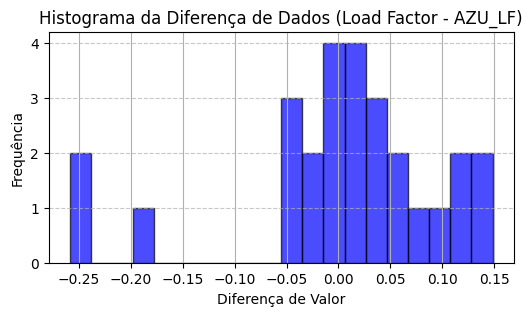

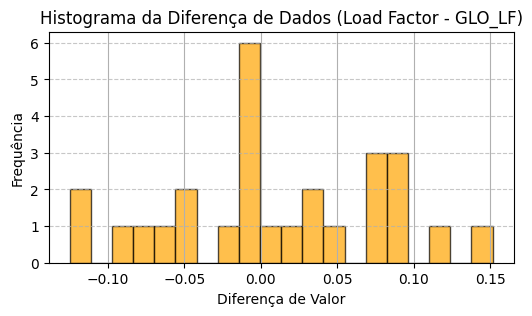

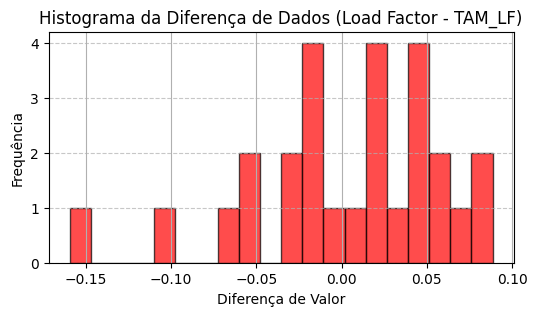

In [66]:
# 4.1.3 Gráfico de Diferenças

# Plota o gráfico de diferenças do Load Factor das companhias aéreas
# Periodo em que as 3 cias aéras operarm juntas (set/2019 a abr/2026)

df_dif = pd.DataFrame()

# 1. Plota o gráfico de diferenças
# 2. Aplicando a diferenciação (diferença entre o valor atual e o anterior)
# O primeiro valor se tornará NaN, então removemos com dropna()

df_dif = df_corr.diff().dropna()
for idx, sigla in enumerate(SIGLA_CIAS_AEREAS):
  # Filtra a cia aérea atual
  df_dif[campo[idx % len(campo)]] = df_corr[campo[idx % len(campo)]].diff().dropna()

  # 3. Plotando o histograma da diferença de dados
  plt.figure(figsize=(6, 3))
  df_dif[campo[idx % len(campo)]].hist(bins=20, color=COR[idx % len(COR)], edgecolor='black', alpha=0.7)

  # 4. Formatando o gráfico
  plt.title('Histograma da Diferença de Dados (Load Factor - '+campo[idx % len(campo)]+')')
  plt.xlabel('Diferença de Valor')
  plt.ylabel('Frequência')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Análise dos Gráficos de Diferenças**

Os gráficos de diferença mostram o comportamento da gestão do Load Factor na Ponte Aérea por cada companhia.

Pelos histogramas de diferenças plotados, verifica-se que a AZUL possui uma concentração maior no lado positivo indicando um crescimento desse indicador.

O histograma de diferença da GOL apresenta uma variação alta no centro e um espalhamento similar em ambas as laterais indicando que esse indicador se encontra estável.

Para a TAM, o histograma de diferença apresenta uma concentração um pouco maior do lado direito indicando um pequeno crescimento desse indicador.

###4.1.4 Matriz de Correlação

A análise da matriz de correlação pode auxiliar uma companhia aérea na identificação de qual companhia aérea concorrente deve ser tratada como uma concorrente direta, porque, uma correlação positiva relevante entre essas companhias, indica que uma está próxima da outra e para uma companhia ganhar a faixa de mercado da outra será mais difícil.


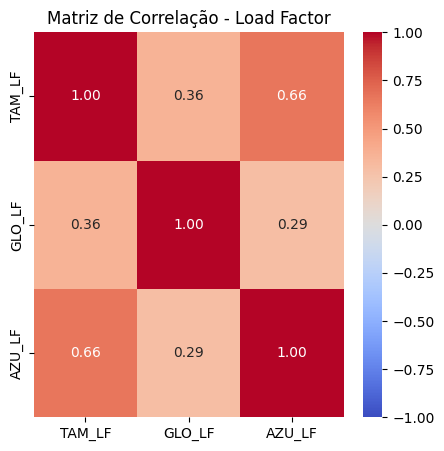

In [67]:
# 4.2.3 Matriz de Correlação

# Plota a matriz de correlação dos Load Factor das Companhias Aéreas
# Periodo em que as 3 cias aéras operarm juntas (set/2019 a abr/2026)

matriz_correlacao = df_corr.corr()

# 3. Plotando o gráfico de matriz de correlação (Heatmap)
plt.figure(figsize=(5, 5))
plt.title('Matriz de Correlação - Load Factor')
sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.2f'
)
plt.show()

**Análise da Matriz de Correlação**

A análise da matriz de correlação do Load Factor das companhias aéreas indica que a Azul e a TAM possuem uma correlação positiva rasoável indicando que a gestão de ambas é parecida, porque respondem na mesma direção aos fatores que afetam a Ponte Aérea acirrando a briga por este mercado.

Em contrapartida, a GOL não se alinha à AZUL e à TAM, pois apresenta uma correlação fraca com essas companhias.


##4.2 Síntese da Análise Exploratória

O conjunto de dados de 'Estatisticas_Ponte_Aerea.csv' apresenta 725 instâncias com 18 atributos categóricos, 21 atributos numéricos e um atributo do tipo data.

Somente os atributos RPK, ASK, ANO e MES serão utilizados para criar os novos atributos da série temporal. Após a criação da série temporal, esses atributos e aqueles que não foram utilizados, serão descartados.

Somente o atributo 'DATA' e a variável target 'LF', Load Factor, foram analisadas, porque os outros atributos não serão utilizados no aprendizado de máquina. A listagem de valores nulos apresentou 4 valores faltantes no atributo 'LF', que serão tratados antes da etapa de aprendizado de máquina.

Não foram encontrados dados duplicados indicando que o conjunto de dados possui uma maior confiabilidade de imputação dos dados no banco de dados.

Na análise do Load Factor das companhias aéreas, verificou-se que a AZUL e a TAM possuem um modelo de gestão parecido e essas companhias disputam mais acirradamente o mercado da Ponte Aérea. Em contrapartida, a GOL se mantém estável no mercado e parece não querer brigar com as concorrentes para aumentar a sua fatia de mercado.



#5 Análise Estatística dos Dados

##5.1 Seleção da Companhia Aérea

Antes de aplicar qualquer ajuste no conjunto de dados para criar a série temporal, será necessário selecionar a companhia aérea que fornecerá os dados para treinar os modelos de aprendizado de máquina. Na ponte aérea Rio-São Paulo estão disponíveis as companhias aéreas Azul (sigla AZU), GOL (sigla GLO) e TAM (sigla TAM).

Para o MVP foi serionada a empresa aérea GOL.

In [68]:
# 5.1 Seleção da Companhia Aérea

# Seleciona a companhia aérea GOL para ser tratada pelo MVP

# AZUL
#CIA_AEREA = 'AZU'

# GOL
CIA_AEREA = 'GLO'

# LATAM
# CIA_AEREA = 'TAM'

# Cria um novo dataframe somente com os voos da companhia aérea selecionada
df_2 = df_1.loc[(df_1['EMPRESA_SIGLA'] == CIA_AEREA)].copy()


##5.1 Decomposição da Série Temporal

Será feita a decomposição da série temporal da companhia aérea seleciona para identificar o comportamento da sazonalidade, tendência e do resíduo.

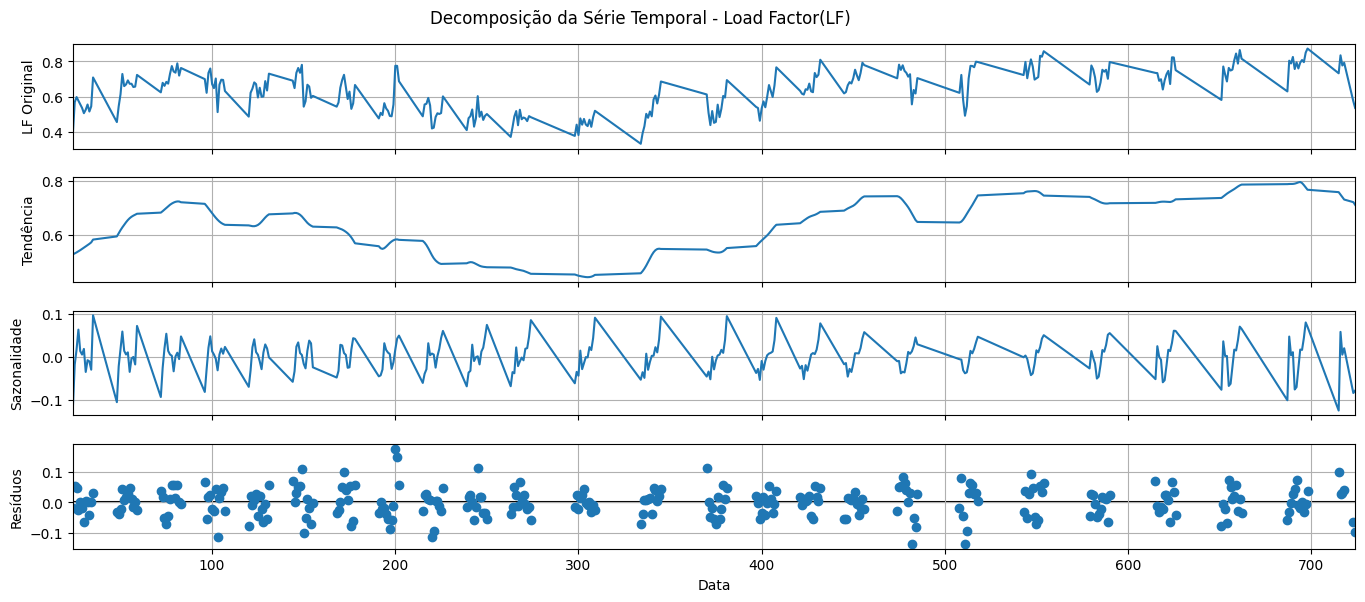

In [69]:
# 5.1 Decomposição da Série Temporal

# Separa a série de Load Factor em tendência, sazonalidade e resíduos

# Faz uma cópia do dataframe e o prepara para plotar os gráficos de decomposição
df_graf = df_2.copy()

# Prepara o dataframe e interpola os valores com NaN
df_graf['LF'] = interpola_LF(df_graf['LF'])
# Ordena o dataframe pelo atributo 'DATA'
df_graf.sort_index(inplace=True)

# Aplica o STL para separar as a série temporal em tendência, sazonalidade e resíduos
stl = STL(df_graf['LF'], period=12, seasonal=13)
resultado = stl.fit()

# Visualização dos componentes
fig = resultado.plot()

fig.set_size_inches((15, 6))
fig.axes[0].set_title('')
fig.axes[0].grid(True)
fig.suptitle("Decomposição da Série Temporal - Load Factor(LF)")
fig.axes[0].set_ylabel("LF Original")
fig.axes[1].set_ylabel("Tendência")
fig.axes[1].grid(True)
fig.axes[2].set_ylabel("Sazonalidade")
fig.axes[2].grid(True)
fig.axes[3].set_ylabel("Resíduos")
fig.axes[3].set_xlabel("Data")
fig.axes[3].grid(True)
plt.show()

##5.2 Distribuição do Resíduo

A distribuição do resíduo será plotada para identificar se essa componente possui somente ruído.



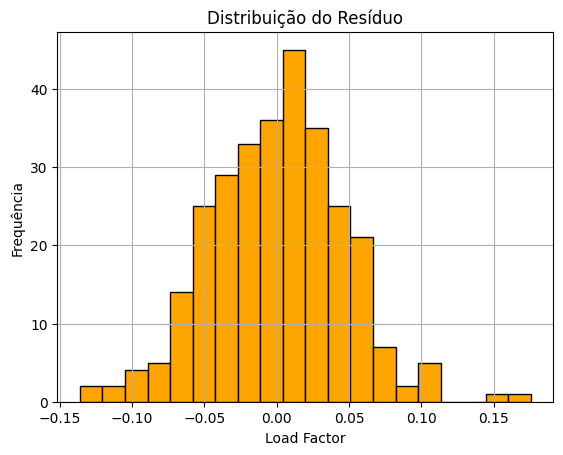

In [70]:
# 5.2 Distribuição do Resíduo

# Plota o histograma do resíduo do Load Factor da GOL
resultado.resid.hist(bins=20, color='orange', edgecolor='black')
plt.title('Distribuição do Resíduo')
plt.xlabel('Load Factor')
plt.ylabel('Frequência')
plt.show()


**Análise da Decomposição da Série Temporal**

Foi utilizada a classe STL, decomposição de tendência sazonal com regressão ponderada local (LOESS), para obter as componentes de tendência, sazonalidade e resíduos da série temporal do Load Factor da companhia aérea. Seguem os comentários:

- Tendência - O gráfico da componente de tendência mostra que o Load Factor está aumentando ou diminuindo ao longo do tempo, ou seja, a série não é estacionária. Será necessário utilizar um polinomio de grau n para prever essa componente e adicioná-la à previsão do Load Factor feita pelo modelo de aprendizado do máquina.

- Sazonalidade - Analisando cuidadosamente o gráfico da componente de sazonalidade, verifica-se que o Load Factor possui uma periodicidade anual e que a variação sazonal é praticamente constante ao longo do tempo, ou seja, os picos e vales no período de um ano se mantêm praticamente na mesma intensidade e amplitude ao longo de todo o período analisado e não sofre influência do crescimento ou queda da linha de tendência. Como a variação sazonal é constante ao longo do tempo, será utilizado o modelo de decomposição aditivo para recompor o valor de Load Factor predito.

- Resíduos - Conforme o histograma acima, a distribuição do resíduo é aproximadamente gaussiana indicando que a variação é puramente ruído e que a tendência e a sazonalidade foram extraídas com sucesso.



##4.3 Gráfico de Autocorrelação Parcial (PACF)

Foi utilizado autocorrelação parcial para determinar o número de atrasos (Lags) que deverão ser implementados na série temporal para otimizar o aprendizado de máquina.

Com a definção do número de atrasos, será necessário criar o mesmo número de atributos de atraso na série temporal.

A otimização dos lags é importante para minimizar o erro de predição dos modelos, economizar memória e tempo de processamento caso a série temporal seja muito grande.

<Figure size 4500x900 with 0 Axes>

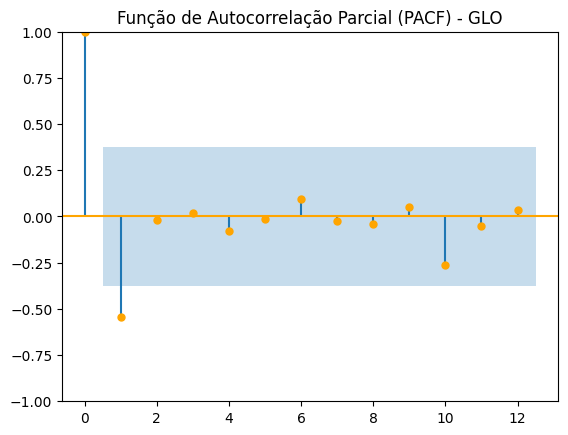

In [71]:
# 4.3 Gráfico de Autocorrelação Parcial (PACF)

# Plota o gráfico de autocorrelação parcial do Load Factor da companhia aérea
for idx, sigla_cia in enumerate(SIGLA_CIAS_AEREAS):
  # Plota o gráfico com o intervalo de confiança de 95% (sombreado em azul)
  if sigla_cia == CIA_AEREA:
    plt.figure(figsize=(15, 3), dpi=300)
    plot_pacf(df_dif[campo[idx]], color=COR[idx], lags=12)
    plt.title("Função de Autocorrelação Parcial (PACF) - " + sigla_cia)
    plt.show()



**Análise do Gráfico de Autocorrelação**

Para a GOL, o gráfico apresenta um corte abrupto no atraso 1 e que se situa na área de significância (fora da área sombreada) indicando que esse atraso é o ponto de maior importancia estatística da séria temporal. Todos os outros pontos se localizam dentro do intervalo de confiança de 95%. Antes da divisão dos dados entre treino e teste, será necessário criar um atributo com atraso de 1 para maximizar o processamento do aprendizado de máquina.

#6 Preparação dos Dados

##6.1 Configuração do Problema

Considerando o conjunto de dados original, somente os atributos 'ANO', 'MES', 'RPK' e 'ASK' serão utilizados para criar o conjunto de dados da série temporal. Após a transformação dos atribuos 'ANO' e 'MES' no atributo 'DATA' e dos atributos 'RPK' e 'ASK' no atributo 'LF' (Load Factor), somente os atributos 'DATA' e 'LF' serão utilizados no conjunto de dados básico para criar a série temporal. A partir do atributo "LF', serão criados os atributos 'LF_1': 'LF' em (t-1); 'med_LF': média do 'LF'; 'std_LF': desvio padrão do 'LF'; 'min_LF' valor mínimo do 'LF' e 'max_LF' valor máximo do 'LF'.



In [72]:
# 6.1 Configuração do Problema

# Identifica as colunas que serão aplicadas no modelo de séries temporais
TIPO_DE_PROBLEMA = 'Série Temporal'
TARGET = 'LF'
COLUNAS_ID = [
    'EMPRESA_SIGLA',
    'AEROPORTO_DE_ORIGEM_SIGLA',
    'AEROPORTO_DE_DESTINO_SIGLA'
]
COLUNA_DATA = 'DATA'
COLUNAS_P_EXCLUSAO = [
    'EMPRESA_NOME',
    'ANO',
    'MES',
    'AEROPORTO_DE_ORIGEM_NOME',
    'AEROPORTO_DE_ORIGEM_UF',
    'AEROPORTO_DE_ORIGEM_REGIAO',
    'AEROPORTO_DE_ORIGEM_PAIS',
    'AEROPORTO_DE_ORIGEM_CONTINENTE',
    'AEROPORTO_DE_DESTINO_NOME',
    'AEROPORTO_DE_DESTINO_UF',
    'AEROPORTO_DE_DESTINO_REGIAO',
    'AEROPORTO_DE_DESTINO_PAIS',
    'AEROPORTO_DE_DESTINO_CONTINENTE',
    'NATUREZA', 'GRUPO_DE_VOO',
    'PASSAGEIROS_PAGOS',
    'PASSAGEIROS_GRATIS',
    'CARGA_PAGA_KG',
    'CARGA_GRATIS_KG',
    'CORREIO_KG',
    'ASK',
    'RPK',
    'DECOLAGENS',
    'CARGA_PAGA_KM',
    'CARGA_GRATIS_KM',
    'CORREIO_KM',
    'ASSENTOS',
    'PAYLOAD',
    'HORAS_VOADAS',
    'BAGAGEM_KG',
    'EMPRESA_NACIONALIDADE',
    'ATK',
    'RTK',
    'COMBUSTIVEL_LITROS',
    'DISTANCIA_VOADA_KM'
]

colunas_p_exclusao = set(COLUNAS_ID + COLUNAS_P_EXCLUSAO)
atributos = [c for c in df_2.columns if c not in colunas_p_exclusao and c != TARGET]

# Elimina as colunas que não serão utilizadas
df_2 = df_2.drop(list(colunas_p_exclusao), axis=1, errors='ignore')

print("Tipo de problema:", TIPO_DE_PROBLEMA)
print("Target:", TARGET)
print("Número de atributos:", len(atributos))
print("Atributos:", atributos)

Tipo de problema: Série Temporal
Target: LF
Número de atributos: 1
Atributos: ['DATA']


##6.2 - Divisão dos Dados - Treino e Teste

Para dividir os dados entre treino e teste foi utilizada a classe TimeSeriesSplit que divide o conjunto de dados em dobras temporais sequenciais para evitar o vazamento de dados.



In [73]:
# 6.2 - Divisão dos Dados - Treino e Teste

# Ordena o dataframe pelo atributo 'DATA'
df_2['DATA'] = pd.to_datetime(df_2['DATA'])

# Transforma a coluna de data no índice do DataFrame
df_2.set_index('DATA', drop=True, inplace=True)

# Inicialize a validação temporal com 5 divisões
tscv = TimeSeriesSplit(n_splits=5)

# Fornece os conjuntos de treino e teste para cada dobra
for fold, (train_index, test_index) in enumerate(tscv.split(df_2)):
    X_treino, X_teste = df_2.iloc[train_index], df_2.iloc[test_index]
    y_treino, y_teste = df_2.iloc[train_index], df_2.iloc[test_index]

y_treino = interpola_LF (y_treino) # Interpola linearmente LF com valores NaN
X_treino, y_treino = desfasa_LF (X_treino, y_treino) # Desloca LF em X_treino
X_treino, y_treino = calc_estatisticas_LF(X_treino, y_treino) # Calcula estatísticas de X_treino

# Após o tratamento do conjunto de X_treino, decomponhe X_treino em sazonalidade e tendência
# e inclui como atributo de X_treino
X_treino['tendencia'], X_treino['sazonalidade'] = decomposicao_STL(X_treino['LF'])

y_teste = interpola_LF (y_teste) # Interpola linearmente LF com valores NaN
X_teste, y_teste = desfasa_LF (X_teste, y_teste) # Desloca LF em X_teste
X_teste, y_teste = calc_estatisticas_LF(X_teste, y_teste) # Calcula estatísticas de X_teste

print("Treino:", X_treino.shape, "|", y_treino.shape, "|", "Teste:", X_teste.shape, "|", y_teste.shape)


Treino: (237, 8) | (237, 1) | Teste: (45, 6) | (45, 1)


##6.3 - Expansão dos Dados

O conjunto de dados original possui somente 237 instâncias. Para treinar um modelo de aprendizado de máquina será necessário adicionar mais instâncias à serie temporal. Como a periodicidade dos dados é mensal, serão adicionadas instâncias diárias. Para preencher esses novos valores de 'LF', será utilizado interpolação linear.

In [74]:
# 6.3 Expansão dos Dados

# Cria as instãncias diárias com o valor do atributo 'LF' interpolado
X_treino = X_treino.asfreq('D').interpolate(method='linear').dropna()
y_treino = y_treino.asfreq('D').interpolate(method='linear').dropna()

print("Treino:", X_treino.shape, "|", y_treino.shape, "|", "Teste:", X_teste.shape, "|", y_teste.shape)

Treino: (7245, 8) | (7245, 1) | Teste: (45, 6) | (45, 1)


Após a expansão dos dados, o númereo de instâncias do treino passou de 237 para 7245.

##6.4 Justificativa da Divisão

Para séries temporais é necessário utilizar a classe TimeSeriesSplit. Ela implementa a validação cruzada que divide os dados ordenados por tempo em conjuntos de treino e teste, preservando a ordem cronológica para evitar vazamento de dados.

Após a expansão dos dados, X_treino foi dividido em 5 dobras deixando 1449 instâncias para treinamento por dobra.

#7 Pré-processamento

Para implementar a série temporal, foram criados os seguintes atributos derivados do atributo target 'LF':

- 'LF_1': 'LF' no tempo (t-1);
- 'LF_med': média dos valores de 'LF';
- 'LF_std': desvio padrão dos valores de 'LF';
- 'LF_min': valor mínimo de 'LF';
- 'LF_max': valor máximo de 'LF';
- 'tendencia': valor da componente de tendência; e
- 'sazonalidade': valor da componente de sazonalidade.

**OBSERVAÇÕES:**
- Somente um atributo de atraso, 'LF_1', foi criado a partir da análise do gráfico de autocorrelação parcial.

- Para os atributos 'LF_med','LF_std', 'LF_min' e 'LF_max', deverá ser determinado experimentalmente o tamanho da janela móvel que minimiza os erros. Para a série temporal da GOL, foi determinado uma janela móvel de tamanho igual a 5.


##7.1 Decisões de Pré-processamento

Para implementar uma série temporal, foi necessário manter somente o atributo 'DATA' e 'LF' do conjunto de dados original e criar novos atributos derivados do 'LF', que foram adicionados à série temporal para auxiliar o aprendizado dos modelos.

Não foi utilizado normalização nos atributos, porque o valor do 'LF' varia entre 0 e 1 e como os outros atributos são derivados do 'LF', todos possuem valores entre 0 e 1.

#8 Baseline e Modelos Candidatos

Para o MVP, o modelo baseline selecionado foi o valor predito como sendo o valor da variável target do dia anterior.

Como o problema é de previsão de um valor utilizando séries temporais, serão utilizados os modelos baseados em árvore de desição: Random Forest Regressor, XGBoost Regressor, Light_GBM Regressor.


In [75]:
# 7 Baseline e Modelos Candidatos

# Cria um pipeline para o processamento de cada modelo

candidatos = {
    'Random Forest Regressor': Pipeline(steps=[
        ('modelo', RandomForestRegressor(n_estimators=200,
                                         max_depth=3,
                                         min_samples_split=9,
                                         random_state=SEED,
                                         max_features=2))
        ]),

    'XGBoost Regressor': Pipeline(steps=[
        ('modelo', XGBRegressor(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=5,
                colsample_bytree=0.8,
                subsample=0.8,
                random_state=SEED))
        ]),

    'Light_GBM Regressor': Pipeline(steps=[
        ('modelo', lgb.LGBMRegressor(
            objective='regression',
            learning_rate=0.001,
            n_estimators=100,
            max_depth = 2,
            random_state = SEED,
            verbosity=-1,
            subsample=0.7,
            colsample_bytree = 0.3))
         ])
}
#model__max_depth': 3, 'model__min_samples_split': 9, 'model__n_estimators': 207}
print('Modelos candidatos:', list(candidatos.keys()))

Modelos candidatos: ['Random Forest Regressor', 'XGBoost Regressor', 'Light_GBM Regressor']


##8.1 Justificativa dos Modelos

Os modelos baseados em árvore de decisão XGBoost, LightGBM e Random Forest são modelos específicos para serem utilizados em casos de regressão onde os modelos fazem a interpolação de um dado, mas podem ser aproveitados em séries temporais para extrapolar um dado (para fazer a previsão do dado). Para que isso seja possível, deve-se aplicar a engenharia de dados para criação de novos atributos que reflitam o passado (criação de atributos com atraso, lag). Na realidade, os modelos de aprendizado de máquina não atuarão sobre o conjunto de dados original, mas sobre um conjunto de dados que será modificado pela engenharia de dados para transformá-lo em uma série temporal que possa ser utilizada por esses modelos. Segue uma descrição rápida de cada modelo (Fonte: Internet):

- XGBoost: Altamente eficiente, rápido e excelente para capturar relacionamentos não lineares. Requer menos esforço de pré-processamento.

- LightGBM: Similar ao XGBoost, mas geralmente mais rápido e com menor consumo de memória, sendo ideal para grandes volumes de dados.

- Random Forest: Um modelo em bagging que funciona muito bem para seleção de features, embora possa apresentar limitações ao extrapolar dependências de longo prazo.

Considerando o conjunto de dados que será utilizado no MVP e o desempenho dos modelos de aprendizado de máquina descritos acima, não se identifica a ocorrência de problemas na utilização desses modelos com o conjunto de dados, porque o conjunto de dados é pequeno e não apresenta risco da ocorrência de um alto custo computacional durante a execução de cada modelo.  

Para o conjunto de dados selecionado, não há restrição de interpretabilidade, porque os dados são públicos e o resultado fornecido pelo modelo de aprendizado de máquina será interpretado e utilizado pela própria companhia aérea os gerou para indentificar o comportamento futuro da sua concorrente. Ou seja, as consequências oriundas da aplicação desses resultados ficarão contidas dentro da própria companhia aérea.






#9 Treinamento e Avaliação Inicial

Seguem as premissas que serão utilizadas nesta etapa:

- Os modelos de aprendizado de máquina selecionadados para o treinamento da série temporal são os modelos Random Forest, XGBoost e Light_GBM conforme descrito no item 8.1.

- Os valores dos hiperparâmetros iniciais utilizados pelos modelos foram selecionados de acordo com as recomendações encontradas na documentação de cada modelo.

- Serão utlizadas as métricas MAE, RMSE e	MAPE para avaliar o desempenho de cada modelo.

- Para o baseline será utilizado o modelo ingênuo com o valor futuro sendo exatamente igual ao último valor observado.

- Espera-se que o desempenho dos modelos de aprendizado de máquina supere em 25% o desempenho do modelo baseline.




In [76]:
# 9 Treinamento e Avaliação Inicial

resultados = {}
modelos_treinados = {}
predicoes = {}

# Baseline
# Para o baseline assume que o valor de X_ é igual ao valor do target anterior
y_pred_baseline = X_teste['LF_1']

# Avaliação do baseline
resultados['BaselineTemporal'] = avalia_serie_temporal(y_teste['LF'], y_pred_baseline)
resultados['BaselineTemporal']['Tempo_Treino_Seg'] = 0

# Modelos candidatos
# Atributos utilizados pelos modelos
atributos_modelo = ['LF_1', 'LF_med', 'LF_min','LF_max', 'LF_std','tendencia', 'sazonalidade']
# Utilizado para testes
#atributos_modelo = ['LF_1', 'LF_2', 'LF_3', 'LF_med', 'LF_min','LF_max', 'LF_std','tendencia', 'sazonalidade']
#atributos_modelo = ['LF_1', 'LF_2', 'LF_3', 'LF_4', 'LF_5', 'LF_med', 'LF_min','LF_max', 'LF_std','tendencia', 'sazonalidade']

# Inicialiação de variáveis para serem utizadas pelos gráficos que serão gerados
# com a previsão de cada modelo
cont = 0 # contador
previsao_modelos = {}

# Prevê os valores de 'LF' para cada modelo
for nome, modelo in candidatos.items():
    #print(f'Treinando modelo: {nome}')

    t0 = time.time()

    # Treina os modelos
    modelo.fit(X_treino[atributos_modelo], y_treino)

    # Extrapola tendência e sazonalidade para o período de y_teste
    X_teste['tendencia'], X_teste['sazonalidade'] = predicoes_tendencia_sazonalidade (X_treino['tendencia'], X_treino['sazonalidade'], len(y_teste))

    # Faz a predição
    y_predito_array = modelo.predict(X_teste[atributos_modelo])

    Tempo_Treino_Seg = time.time() - t0

    # Converte o array com as predições para uma serie e alinha os índices com y_teste
    y_predito_series = pd.Series(y_predito_array, index=y_teste.index)

    # Cria um dataframe com as predições de cada modelo para serem utilizados
    # na elaboração de gráficos
    nome_y = 'y_predicoes_serie_' + str(cont)
    previsao_modelos[nome_y] = y_predito_series
    cont += 1

    # Avalia os resultados de cada modelo
    resultados[nome] = avalia_serie_temporal(y_teste['LF'], y_predito_series)
    resultados[nome]['Tempo_Treino_Seg'] = round(Tempo_Treino_Seg, 3)
    modelos_treinados[nome] = modelo

# Armazena a previsão de cada modelo em y_predito
y_predito = previsao_modelos[f'y_predicoes_serie_{cont-1}']

exibe_tabela_resultados(resultados)


,MAE,RMSE,MAPE %,Tempo_Treino_Seg
BaselineTemporal,0.058655,0.076997,7.916904,0.000
Random Forest Regressor,0.061614,0.073931,8.049881,1.215
XGBoost Regressor,0.050816,0.063844,6.882338,0.212
Light_GBM Regressor,0.141146,0.152433,18.056518,0.034


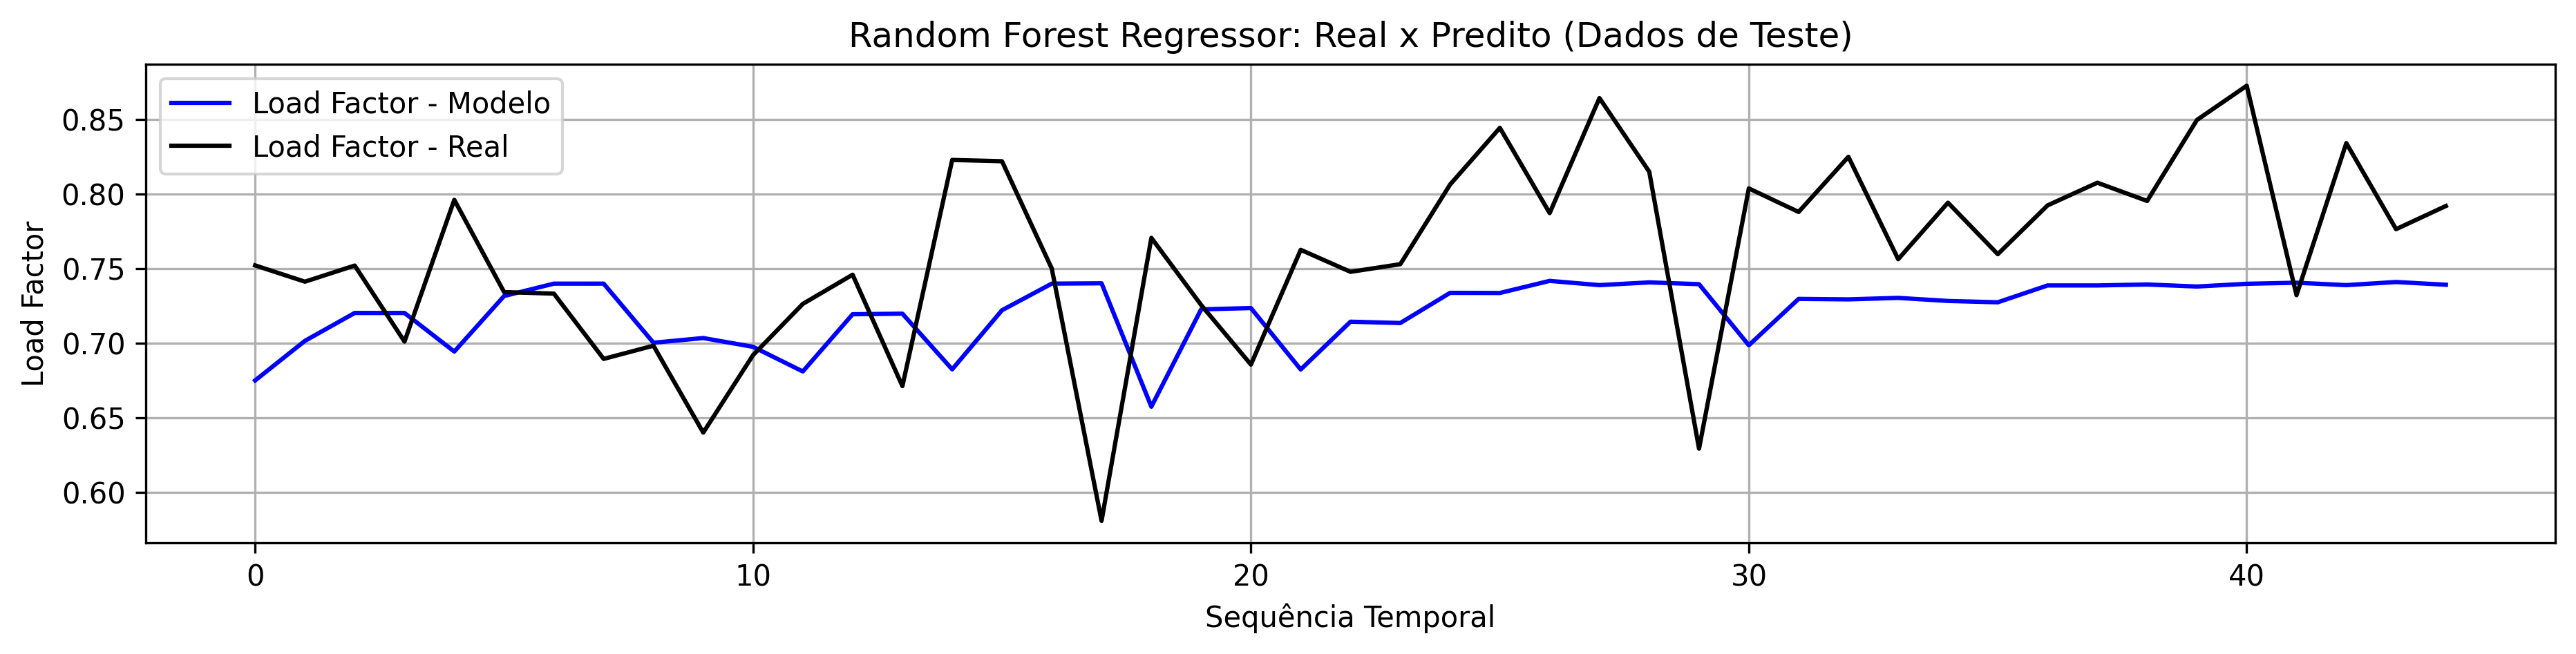

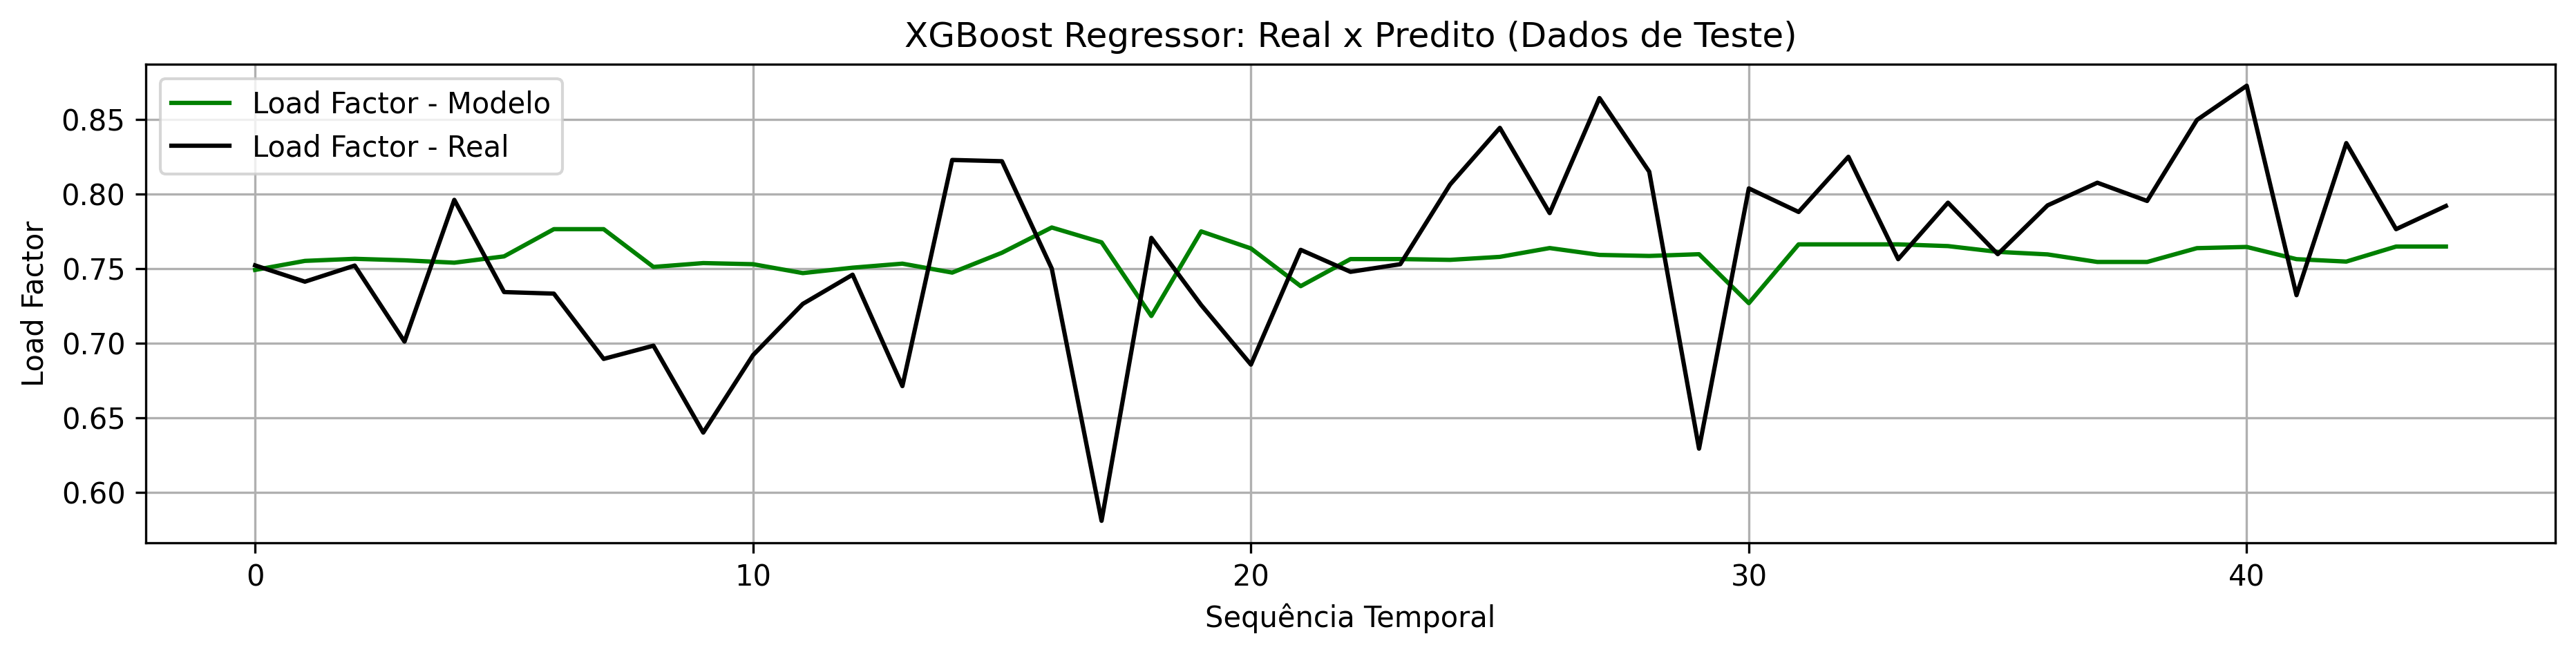

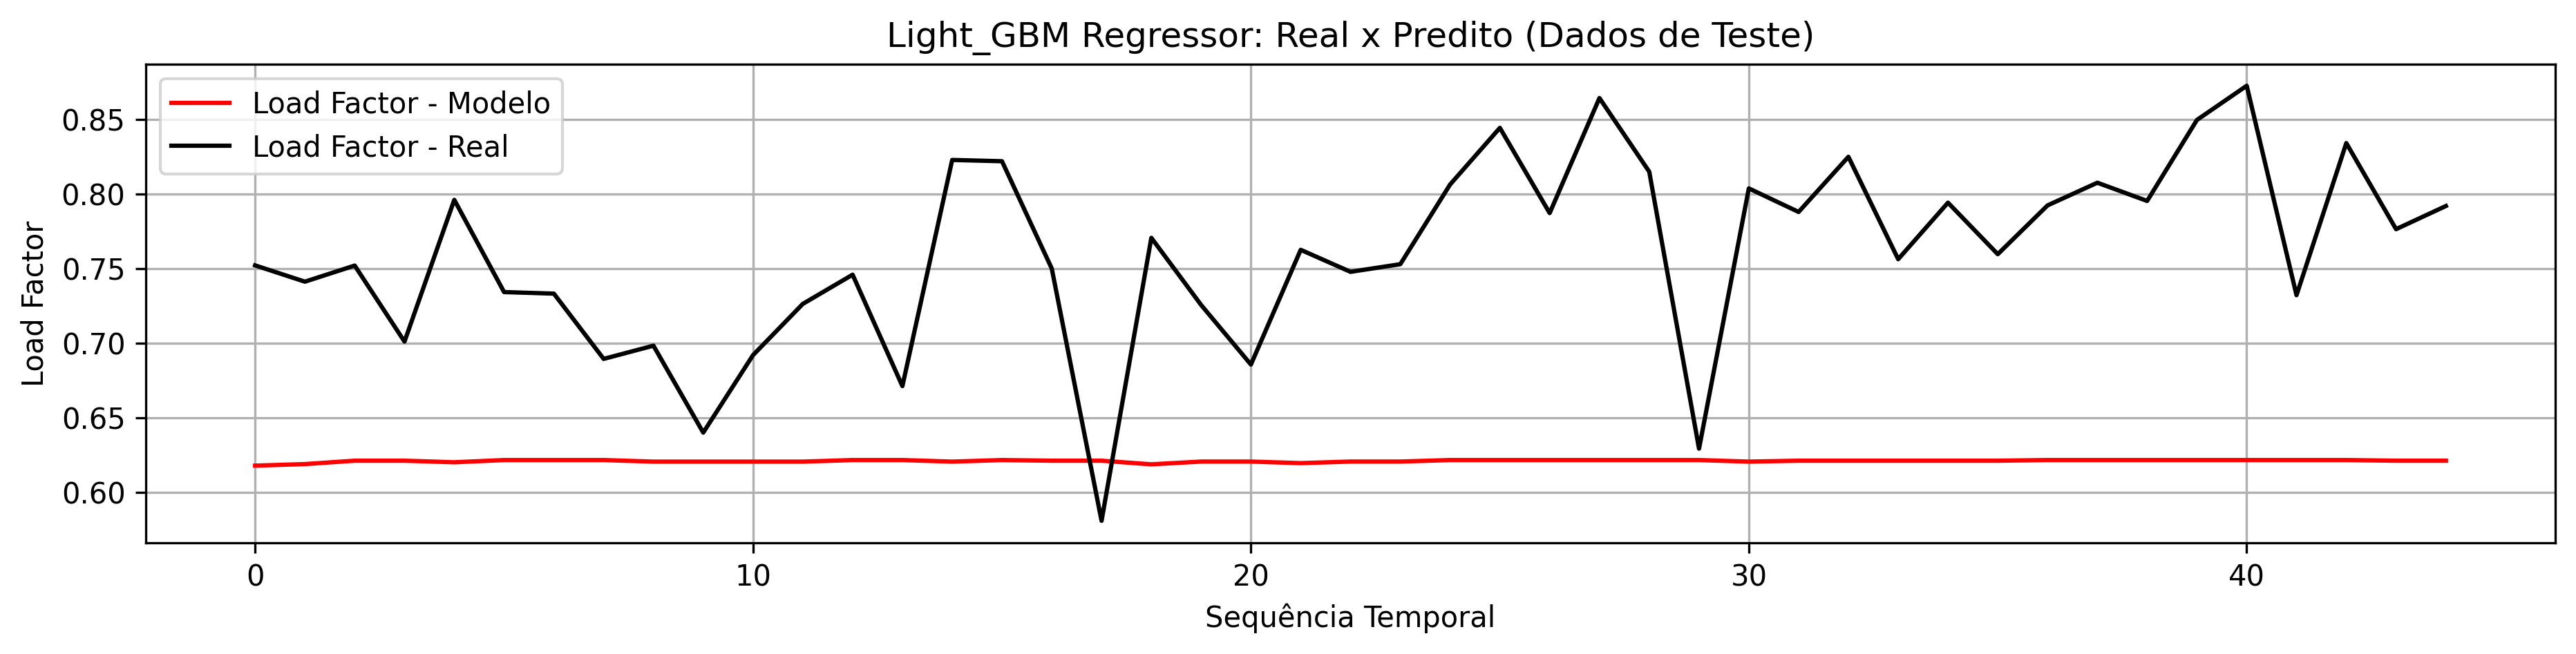

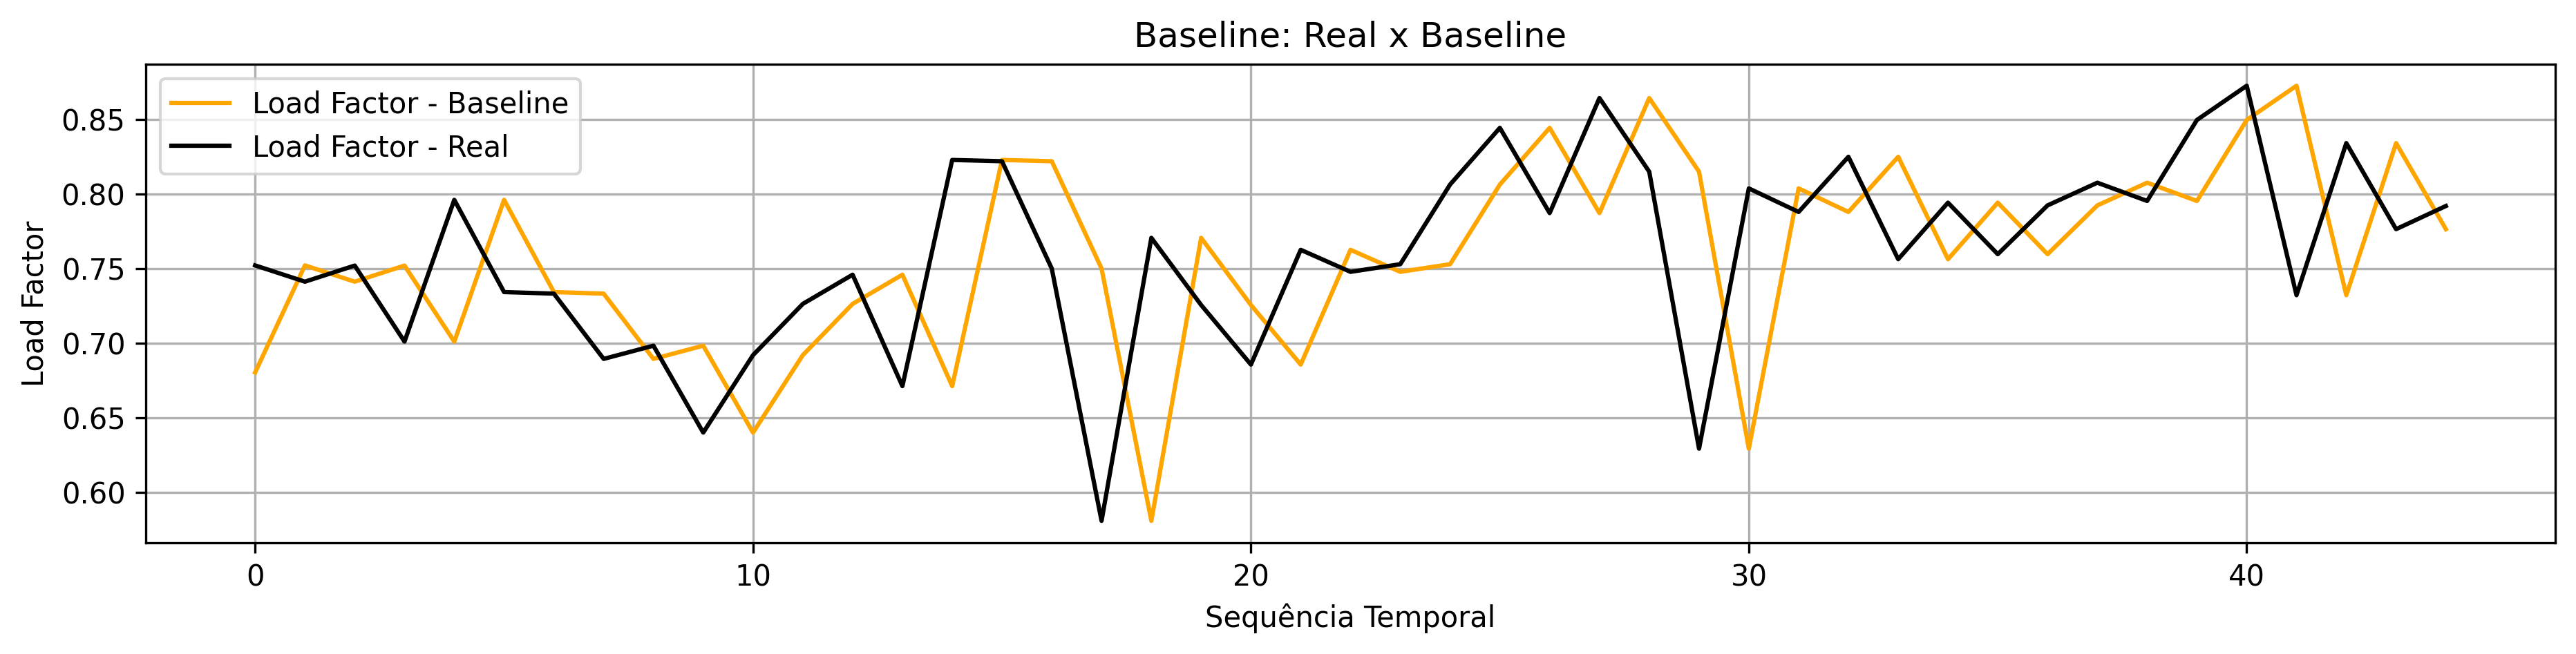

In [77]:
# 9 Treinamento e Avaliação Inicial

# Desfaz a indexação feita por TimeSeriesSplit para apresentar os gráficos
# na sequência temporal correta

# Garante que y_predito é uma série e 0 índice é alinhado com y_teste
y_predito = pd.Series(y_predito, index=y_teste.index) if isinstance(y_predito, np.ndarray) else y_predito

y_predicoes_limpo = y_predito.reset_index(drop=True)
y_teste_limpo = y_teste.reset_index(drop=True)

# Inicializa as variáveis de modelos e cores
nome_modelos = list(modelos_treinados.keys())
colors_list = ['blue', 'green', 'red']

# Plota uma figura com os valores reais e os valores preditos para cada modelo
for idx, key in enumerate(previsao_modelos):
  plt.figure(figsize=(15, 3), dpi=300)
  current_predictions = previsao_modelos[key]
  if isinstance(current_predictions, np.ndarray):
      current_predictions = pd.Series(current_predictions, index=y_teste.index)
  y_predicoes_limpo = current_predictions.reset_index(drop=True)

  # Plota as predições de cada modelo
  plt.plot(y_predicoes_limpo.index, y_predicoes_limpo, color=colors_list[idx % len(colors_list)], label='Load Factor - Modelo')

  # Plota os valores reais da variável target
  plt.plot(y_teste_limpo.index, y_teste_limpo, color='black', label='Load Factor - Real')
  plt.title(f'{nome_modelos[idx]}: Real x Predito (Dados de Teste)')
  plt.xlabel('Sequência Temporal')
  plt.ylabel('Load Factor')
  plt.legend()
  plt.grid(True)
  plt.show()

# Compara graficamente o BASELINE(t) com o BASELINE(t-1)
plt.figure(figsize=(15, 3),dpi=300)
plt.plot(y_teste_limpo.index,(y_pred_baseline),color='orange', label='Load Factor - Baseline')
plt.plot(y_teste_limpo.index, y_teste_limpo, color='black', label='Load Factor - Real')

plt.title('Baseline: Real x Baseline')
plt.xlabel('Sequência Temporal')
plt.ylabel('Load Factor')
plt.legend()
plt.grid(True)
plt.show()

##9.1 Análise dos Resultados Iniciais

A análise da tabela de resultados indica que somente o modelo XGBoost superou o modelo baseline em 13,36%. Além disso, o modelo XGBoost superou os modelos Random Forest e Light GBM. A tabela abaixo mostra a comparação de cada modelo com o modelo baseline:

| Modelo | Comparação | MAE (%) | RMSE (%) | MAPE (%) |
|---|---|---:|---:|---:|
|XGBoost| Baseline | -13,36 | -17,08 | -13,06 |
|Random Forest| Baseline | 5,04 | -3,98  | 1,67  |
|Light GBM| Baseline | 140,64 | 97,97  | 128,07  |

As métricas selecionadas para availiar os resultados são as mais adequadas para serem utilizadas na previsão de valores por uma série temporal, porque são baseadas na diferença entre o valor real e o valor predito.

Análisando o gráfico que comparara a série temporal de cada modelo com a série real (gráficos acima), verifica-se que a previsão não é muito boa, porque os modelos não acompanham algumas variações mais bruscas da série real. Por esse motivo, o erro RMSE é maior do que o erro MAE em todos os modelos.

Devido a essa dificuldade de previsão dos modelos, nenhum modelo apresentou overfitting. Entretanto, ocorreu underfitting no modelo Light GBM, que, pelo gráfico temporal, apresentou quase uma linha reta para os valores preditos.

Com relação ao tempo de treinamento dos modelos de aprendizado de máquina, o tempo de execução é pequeno e não apresenta problemas.

# 10 Validação e Otimização de Hiperparâmetros

O modelo XGBoost foi configurado com os hiperparâmetros determinados no processo de otimização, mas os resultados não foram tão bons quanto os resultados obtidos no teste utilizando os hiperparâmetros configurados no treinamento.

- Segue a comparação dos valores obtidos:

| 	|  | MAE |	RMSE |	MAPE % |	Tempo_Treino_Seg |
|---|---|---:|---:|---:|---:|
| Teste | XGBoost Regressor |	0.050816 |	0.06.3844 |	6.8823 |	0.437 |
| Otimização | XGBoost Regressor |	0.054396 |	0.067071 |	7.3178 |	0.115 |

- Comparação entre os hiperparâmentros utilizados no teste e na otimização:

| Etapa	| n_estimators | learning_rat |	max_depth |	colsample_bytree |	subsample | random_state |
|---|---:|---:|---:|---:|---:|---:|
| Teste	| 100 | 0.05000000000000 |	5 |	0.8000000000000 |	0.8000000000000 | SEED |
| Otimização	| 137 | 0.06543795882193644 |	3 |	0.4142934543375526 |	0.9659541126403375 | SEED |

In [78]:
# 10  Validação e Otimização de Hiperparâmetros

# Modelo
modelo_p_ajuste = Pipeline(steps=[
    ('model', XGBRegressor(random_state=SEED))
])

# Parâmetros que serão otimizados
distribuicao_parametros = {
    "model__n_estimators": randint(50, 250),
    "model__max_depth": randint(2, 20),
    "model__learning_rate": uniform(loc=0.001, scale=0.099),
    "model__colsample_bytree": uniform(loc=0.3, scale=0.8),
    "model__subsample": uniform(loc=0.3, scale=0.8),
    }

# Número de configurações aleatórias
N_ITER_SEARCH = 10

# Configura o TimeSeriesSplit com 5 divisões
tscv = TimeSeriesSplit(n_splits=5)

# Métrica utilizada para comparação
metrica = "neg_root_mean_squared_error"

# Atributos utilizados pelo modelo
atributos = ['LF_1', 'LF_med', 'LF_std', 'LF_min', 'LF_max', 'tendencia', 'sazonalidade']
# Utilizado para testes
#atributos = ['LF_1', 'LF_2', 'LF_3', 'LF_med', 'LF_min','LF_max', 'LF_std','tendencia', 'sazonalidade']
#atributos = ['LF_1', 'LF_2', 'LF_3', 'LF_4', 'LF_5', 'LF_med', 'LF_min','LF_max', 'LF_std','tendencia', 'sazonalidade']

search = RandomizedSearchCV(
    estimator = modelo_p_ajuste,
    param_distributions = distribuicao_parametros,
    n_iter = N_ITER_SEARCH,
    cv = tscv,
    scoring = metrica,
    random_state = SEED,
    n_jobs = 1,
    verbose = 1
)
# Procura pelos melhores hiperparâmetros utilizando os conjuntos de treino
# divididos por TimeSeriesSplit
search.fit(X_treino[atributos], y_treino)

print("Melhor pontuação na avaliação:", search.best_score_)
print("Melhores hiperparâmetros     :", search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor pontuação na avaliação: -0.05064161941409111
Melhores hiperparâmetros     : {'model__colsample_bytree': np.float64(0.4142934543375526), 'model__learning_rate': np.float64(0.06543795882193644), 'model__max_depth': 3, 'model__n_estimators': 137, 'model__subsample': np.float64(0.9659541126403375)}


## 10.1 Discussão da Otimização

A otimização dos parâmetros do modelo XGBoost não resultou em melhora, apesar do intervalo de busca dos parâmetros serem ajustadas para conter os parâmetros utilizados na aviação dos dados de teste. Além disso, foram utilizadas outras combinações, mas o resultado ficou abaixo do encontrado no teste. Por esse motivo, a configuração utilizada no teste será mantida e a configuração otimizada será descartada.

# 11 Avaliação Final no Conjunto de Teste

Conforme descrito no item 10.1, a melhor estimativa para o modelo XGBoost foi obtida com os parâmetros utilizados no teste. Seguem os dados obtidos:

- Métrica Final:

|  | MAE |	RMSE |	MAPE % |	Tempo_Treino_Seg |
|---|---:|---:|---:|---:|
| XGBoost Regressor |	0.050816 |	0.063844 |	6.8823 |	0.437 |


- Comparação do modelo XGBoost com o modelo baseline:

|  | MAE |	RMSE |	MAPE % |	Tempo_Treino_Seg |
|---|---:|---:|---:|---:|
| Baseline | 0.058655 | 0.076997 | 7.9169 | 0.000 |
| XGBoost Regressor |	0.050816 |	0.063844 |	6.8823 |	0.437 |

- Análise dos Erros:

Como os hiperparâmetros otimizados serão os mesmos utilizados no teste, a análise dos erros é a mesma que foi descrita no item 9.1.

- Identificação de Overfitting/Underfitting:

Como os hiperparâmetros otimizados serão os utilizados no teste, a análise da para identificar a ocorrência de overfitting ou underfitting é a mesma que foi apresentada no item 9.1.

- Limitações da Solução:

Não foi possível atender ao requisito inicial de que o erro do modelo de aprendizado de máquina superasse o modelo baseline em 25%. Na melhor estimativa, o modelo XGBoost superou o modelo baseline em 13,07% (MAPE). Isso demonstra que o modelo possui uma limitaçao na previsão da variável target Load Factor utilizando a série temporal obtida a partir do conjunto de dados original.


## 11.1 Análise de Erros e Limitações

Os resultados obtidos foram rasoáveis considerando que o ganho esperado para os modelos sobre o modelo baseline foi estabelecido em 25% e o menor erro encontrado nos modelos foi no modelo XGBoost, que ficou 13,07% (MAPE) melhor que o modelo baseline.

Durante o treinamento dos modelos não ocorreu overfitting. Entretanto, ocorreu underfitting no modelo Light_GBM, que não conseguiu aprender os padrões corretamente e apresentou uma linha quase que totalmente reta para o valor da variável target (Gráfico "Light_GBM Regressor: Real x Predito (Dados de Teste)" no item 9).

Apesar do conjunto de dados original possuir dados dos anos de 2000 a 2026, os dados são mensais e isso limitou o número de dados disponíveis para o treinamento e para o teste. A inclusão de dias entre os meses, utilizando interpolação linear, diminuiu um pouco os erros, mas não serviu para predizer as variações mais abruptas da série temporal real conforme os gráficos temporais apresentados no item 9).

Outro ponto importante que deve ser destacado foi a utilização do gráfico de autocorrelação parcial, que determinou que somente o atraso 1 (lag (t-1)) deveria ser incluído como atributo da série temporal.

Nos atributos estatísticos média, desvio padrão, mínimo e máximo o número de janelas móveis foi variado de 1 a 6 e o resultado que apresentou o menor erro (MAE) foi com o número de janelas igual a 5 (Tabela abaixo).


| Atrasos	| Janelas | Modelo | MAE |	RMSE |	MAPE % |	Tempo_Treino_Seg |
|---|---|---|---:|---:|---:|---:|
| 1 | 2 | XGBoost Regressor |	0,053568 |	0.066975 | 7.1335 |	0.090 |
| 1 | 3 | XGBoost Regressor |	0,052670 |	0.064750 | 7.1007 |	0.089 |
| 1 | 4 | XGBoost Regressor |	0,050832 |	0.063442 | 6.8512 |	0.798 |
| 1 | 5 | XGBoost Regressor |	0,050816 |	0.063844 | 6.8823 |	0.584 |
| 1 | 6 | XGBoost Regressor |	0,052681 |	0.066508 | 7.1374 |	0.118 |

A decomposição da série temporal em tendência, sazonalidade e resíduos também contribuiu para melhorar o desempenho preditivo dos modelos. Conforme a tabela abaixo, a utilização de um polinômio de segunda ou de terceira ordem apresentou o mesmo erro, que foram os menores erros encontrados para a variação do grau desse polinômio.

| Grau Polinômio | Modelo | MAE |	RMSE |	MAPE % |	Tempo_Treino_Seg |
|---|---|---:|---:|---:|---:|
| 1 | XGBoost Regressor |	0.140225 |	0.150636 | 17.9778 |	0.946 |
| 2 | XGBoost Regressor |	0.050816 |	0.063844 | 6.8823 |	0.087 |
| 3 | XGBoost Regressor |	0.050816 |	0.063844 | 6.8823 |	0.090 |
| 4 | XGBoost Regressor |	0.088904 |	0.100237 | 11,3953 |	0.087 |

Seguem os erros para o modelo XGBoost, que obteve o melhor desempenho na previsão da variável target (Para os outros modelos o resultado foi o mesmo).

| Modelo | MAE |	RMSE |	MAPE % |	Tempo_Treino_Seg |
|---|---:|---:|---:|---:|
| BaselineTemporal |	0.058655 |	0.076997 |	7.9169 |	0.000 |
| Random Forest Regressor |	0.061614 |	0.073931 |	8.0499 |	1.210 |
| XGBoost Regressor |	0.050816 |	0.063844 |	6.8823 |	0.094 |
| Light_GBM Regressor |	0.141146 |	0.152433 |	18.0565 |	0.035 |

# 12. Comparação Final dos Modelos

Segue uma síntese comparando as métricas encontradas para cada modelo.

| Modelo | Métrica principal (MAE) | Outras métricas (MAPE %) | Tempo de treino (s) | Observações |
|---|---:|---:|---:|---|
| Baseline | 0.058655 | 7.916904 | 0.000 |  |
| Random Forest | 0.061614 | 8.049881 | 1203 |  |
| Light_GBM | 0.141146 | 18.056518 | 0.029 |  |
| XGBoost | 0.050816 | 6.882338 |  0.087 | |
| Modelo otimizado | 0.050816 | 6.882338 | 0.087 | Igual ao XGBoost |


# 13. Boas Práticas e Rastreabilidade

A tabela abaixo descreve o que foi feito durante o desenvolvimento do MVP para melhorar o desempenho da previsão.

**Registro de decisões:**

| Decisão | Justificativa | Impacto Esperado |
|---|---|---|
| SEED = 42| Garantir a reprodutibilidade do modelo | Manter os mesmos resultados |
| Grau Polinômio Tendência = 2 | Otimizar o modelo | Diminuir o erro |
| Número de Atrasos da Série Temporal = 1 | Otimizar o modelo | Diminuir o erro |
| Random Forest  | Avaliação do modelo | Prever o target com um erro 25% menor do que o erro do baseline |
| XGBoost  | Avaliação do modelo | Prever o target com um erro 25% menor do que o erro do baseline |
| Light_GBM | Avaliação do modelo | Prever o target com um erro 25% menor do que o erro do baseline |
| Tempo de Treinamento dos Modelos | 1,395 s | Sem impacto |
| Pré-processameto | Não utlizado. Valor entre 0 e 1 normalizado pelo atributo ASK | Sem impacto |
| n_estimators=100 | Otimização | Melhorar desempenho  |
| learning_rate=0.05  |  Otimização | Melhorar desempenho  |
| max_depth=5  |  Otimização | Melhorar desempenho  |
| colsample_bytree=0.8  |  Otimização | Melhorar desempenho  |
| subsample=0.8 | Otimização  |  Melhorar desempenho |
| random_state=SEED | Otimização  |  Melhorar desempenho |

# 14. Conclusão

O objetivo do MVP era predizer o Load Factor de uma companhia aérea na Ponte Aérea Rio-São Paulo e superar o resultado apresentado pelo baseline em 25% utilizando os modelos de aprendizado de máquina XGBoost, Random Forest e Light_GBM.

Após o treinamento inicial, identificou-se que o modelo XGBoost foi superior ao baseline em 13,07% (MAPE) e também foi superior aos modelos Random Forest e Light_GBM.

A adição de novos atributos de atraso, otimização de parâmetros como o grau do polinômio utilizado para prever a tendência e a otimização dos hiperparâmetros do modelo XGBoost, não diminuiram os erros além dos resultados encontrados.

Entretanto, considera-se que a predição apresentada pelo modelo XGBoost é boa, pois apresenta um erro percentual de 6,88%. Considerando que esse valor foi obtido de um conjunto de dados com valores mensais e o indicador Load Factor pode mudar dentro de um período de 30 dias, o erro encontrado foi considerado bom e valida o modelo para ser utilizado por uma companhia aérea para prever o Load Factor das companhias aéreas concorrentes na Ponte Aérea Rio-São Paulo.